<!-- # ADMX Gravitational Wave Pipeline

End-to-end execution notebook.  
**Section 1** runs the full pipeline on a single `.dat` file for rapid validation.  
**Section 2** runs the full pipeline over the entire nibble folder.

Pipeline stages:
```
binned4          →  FFT + receiver template + receiver-flattened complex voltage
hr_raw_prep      →  noise σ cut, PSD estimation, ComplexVoltageSeries packaging
psd_computation  →  cross-scan median noise PSD
create_waveform_template  →  Berlin voltage template (ω=2πf corrected)
matched_filter_core       →  complex SNR, candidate identification, strain limits
```

All timers are printed at each stage boundary. -->

## 0. Imports and configuration

In [1]:
import psutil, gc
vm = psutil.virtual_memory()
print(f"Total:     {vm.total/1e9:.1f} GB")
print(f"Available: {vm.available/1e9:.1f} GB")
print(f"Used:      {vm.used/1e9:.1f} GB")
gc.collect()


# Also check if any large arrays are lingering from previous runs
import sys
large = {k: sys.getsizeof(v)/1e6 for k, v in globals().items() 
         if sys.getsizeof(v) > 50e6}
print("Large objects in memory:", large)

Total:     17.2 GB
Available: 7.4 GB
Used:      5.1 GB
Large objects in memory: {}


In [2]:
import time
import logging
import warnings
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py
from pycbc.types import FrequencySeries

# Pipeline modules
from config_file_handling import RunConfig, parse_filename_timestamp
from admx_db_datatypes import ScanParameters
from binned4 import (
    run_pipeline as binned_run_pipeline,
    process_scan,
    read_dat_file,
    polyphase_fft,
    MODE_PHASE_PRESERVING,
)
from hr_raw_prep import (
    run_hr_raw_prep,
    load_prepared_scan,
    process_binned_h5,
    save_prepared_scan,
    cavity_lorentzian,
)
from psd_computation import (
    run_psd_computation,
    load_psd_h5,
    validate_psd,
    ensure_psd_on_grid,
)
from create_waveform_template import (
    build_template_for_scan,
    plot_template,
    snr_threshold_to_strain,
    berlin_voltage_scale,
    build_superradiant_template,

)
from matched_filter_core import (
    matched_filter_single,
    normalize_template,
    analyze_snr_distribution,
    make_synthetic_injection,
    compute_snr_threshold,
    run_matched_filter_nibble,
)


warnings.filterwarnings('ignore', category=UserWarning)
logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)s %(name)s: %(message)s')
log = logging.getLogger('pipeline_nb')

print('Imports OK')

/Users/chrisewasiuk/miniconda3/envs/pocket/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


Imports OK


In [3]:
# ── Configuration ────────────────────────────────────────────────────────────
RUN_DEFINITION   = 'run1b_definitions.yaml'
NIBBLE_NAME      = 'nibble5'
HR_ROOT          = 'hr_data'
PARAM_DATE       = '2018_05_19'
CHANNEL          = 1

# Resolution: change seg_len to trade off frequency resolution vs file size.
# seg_len=64 → ~0.6 Hz bins for a 100 s scan; seg_len=1 → native (~10 mHz)

SEG_LEN          = 1
CROP_SECONDS     = 2.0
WINDOW           = 'hann'

SIGNAL_TYPE         = 'superradiant'   # 'superradiant' or 'pbh'
F_SIGNAL_OFFSET_HZ  = 0.0          

# Frequency band for matched filter
F_LOW            = 50.0     # Hz (baseband)
F_HIGH           = None     # Hz; set e.g. 48_000 to exclude bandpass edges

# Statistical analysis
TARGET_FALSE_ALARMS = 1.0   # expected false alarms above threshold across nibble

# Output directories
BINNED_DIR    = Path(HR_ROOT) / 'binned_hr_data'
PREPARED_DIR  = Path(HR_ROOT) / 'prepared'
RESULTS_DIR   = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

# Load config
cfg    = RunConfig.from_yaml(RUN_DEFINITION)
nibble = cfg.nibble(NIBBLE_NAME)
print(nibble)
B_FIELD = cfg.b_field(NIBBLE_NAME)
# print(cfg)
print(f'B field = {B_FIELD} T')

prepared_files = sorted(PREPARED_DIR.glob('*_prepared.h5'))
assert len(prepared_files) > 0, f'No prepared HDF5 files found in {PREPARED_DIR}'
print(f'Found {len(prepared_files)} prepared scans')

ref_scan  = load_prepared_scan(prepared_files[0])
sp        = ref_scan['scan_params']
f_bb_arr  = ref_scan['f_baseband']
f_abs_arr = ref_scan['f_abs']
df_       = ref_scan['delta_f_hz']
del ref_scan   # free voltage data — only needed scan_params and axes
gc.collect()




{'data_directory': 'hr_data', 'background_timestamps': ['2018-01-26 12:16:40-08', '2018-01-26 12:20:40-08'], 'Bfield': 7.68, 'candidate_threshhold_sigma': 3.0, 'candidate_threshhold_power': 0.5, 'minimum_snr': 2.4, 'form_factor_file': 'form_factors.yaml', 'hfet_system_noise': 10.0, 'amplifier_noise_mode': 'jpa_advanced', 'jpa_snr_correction': -0.52, 'jpa_probe_digitization_bandwidth_hz': '48.7e3', 'grand_resolution_hz': 350, 'bg_fit_type': 'pade', 'hfet_noise_file': 'run1b_combined_hfet_noise.yml', 'phase_slope_transmission': -1.51, 'phase_slope_reflection': -1.54, 'file_prefix': 'run1b_nibble5', 'start_time': datetime.datetime(2018, 5, 10, 12, 50, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))), 'stop_time': datetime.datetime(2018, 6, 1, 0, 50, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))), 'start_freq': 728.5, 'stop_freq': 741.5, 'receiver_shape': 'run1b_nibble5_receiver_shape.h5', 'spectrum_file_name': '../../data/run1b_nibble5_spectra.h

0

In [4]:
# ── Timer utility ─────────────────────────────────────────────────────────────
_timers = {}

@contextmanager
def timer(label):
    """Context manager that prints elapsed wall time for a pipeline stage."""
    t0 = time.perf_counter()
    print(f'\n▶  {label} …')
    try:
        yield
    finally:
        elapsed = time.perf_counter() - t0
        _timers[label] = elapsed
        mins, secs = divmod(elapsed, 60)
        if mins > 0:
            print(f'✓  {label}  →  {int(mins)}m {secs:.1f}s')
        else:
            print(f'✓  {label}  →  {secs:.2f}s')

def print_timer_summary(label='Pipeline timing summary'):
    print(f'\n{"─"*55}')
    print(f' {label}')
    print(f'{"─"*55}')
    total = 0.0
    for k, v in _timers.items():
        mins, secs = divmod(v, 60)
        tag = f'{int(mins)}m {secs:.1f}s' if mins > 0 else f'{secs:.2f}s'
        print(f'  {k:<42} {tag:>8}')
        total += v
    mins, secs = divmod(total, 60)
    print(f'{"─"*55}')
    tag = f'{int(mins)}m {secs:.1f}s' if mins > 0 else f'{secs:.2f}s'
    print(f'  {"TOTAL":<42} {tag:>8}')
    print(f'{"─"*55}\n')

---
# Section 1 — Single file pipeline
Runs every stage on one `.dat` file so you can inspect each intermediate product before committing to the full run.

<!-- ### 1.1  Pick one file -->

In [5]:
_timers.clear()

# Find all .dat files for this nibble and pick the first one
all_dat = cfg.dat_files(NIBBLE_NAME, hr_root=HR_ROOT, channel=CHANNEL)
print(f'Total .dat files for {NIBBLE_NAME}: {len(all_dat)}')

single_dat = all_dat[0]
print(f'Using: {single_dat.name}')

ts = parse_filename_timestamp(single_dat.name)
print(f'Timestamp (UTC): {ts}')

2026-05-14 12:06:06,713 INFO config_file_handling: glob_hr_dat_files: 105 / 105 files in nibble window [2018-05-10T12:50:00-07:00, 2018-06-01T00:50:00-07:00]


Total .dat files for nibble5: 105
Using: admx_data_2018_05_19_23_00_33_channel_1.dat
Timestamp (UTC): 2018-05-20 06:00:33+00:00


### 1.2  Stage 1 — FFT, polyphase channelisation, receiver template, flattening

Deleted: admx_data_2018_05_19_23_00_33_channel_1_binned.h5

▶  Stage 1 — process single scan …


2026-05-14 12:06:09,837 INFO binned4: Saved -> hr_data/binned_hr_data/admx_data_2018_05_19_23_00_33_channel_1_binned.h5


✓  Stage 1 — process single scan  →  3.10s
N bins: 4,678,096   Δf = 0.010438 Hz
f_abs:  739.9802 – 740.0290 MHz


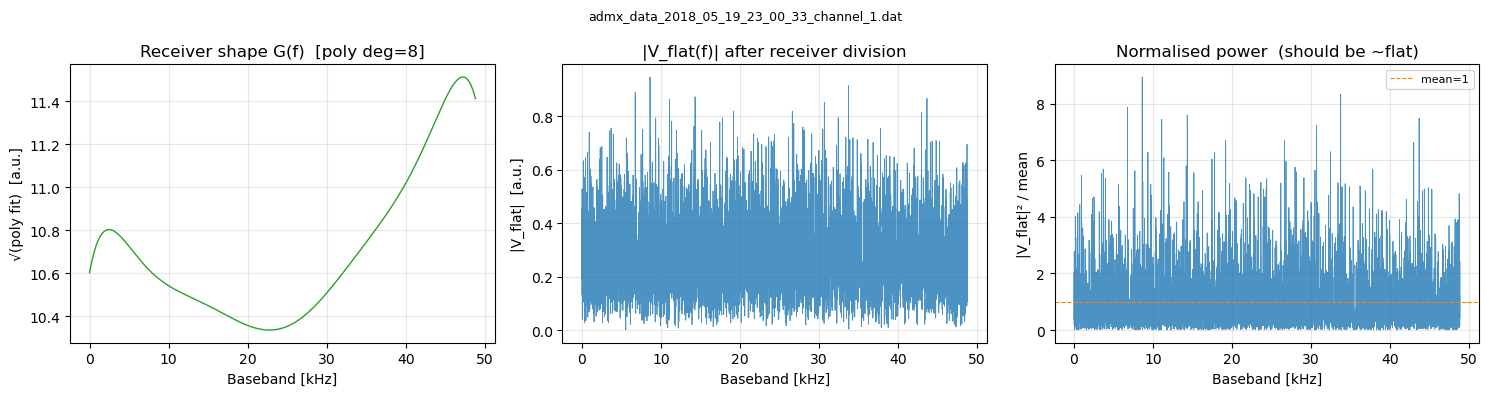

In [6]:
param_df = cfg.load_parameter_df(NIBBLE_NAME, PARAM_DATE)

# Force delete stale H5 before stage 1
stale = BINNED_DIR / f'{single_dat.stem}_binned.h5'
if stale.exists():
    stale.unlink()
    print(f'Deleted: {stale.name}')

with timer('Stage 1 — process single scan'):
    BINNED_DIR.mkdir(parents=True, exist_ok=True)
    result = process_scan(
        path=single_dat,
        param_df=param_df,
        b_field_tesla=B_FIELD,
        seg_len=SEG_LEN,
        crop_seconds=CROP_SECONDS,
        window=WINDOW,
        output_dir=BINNED_DIR,
        overwrite=True,
    )


if result is None:
    print("process_scan returned None — check find_parameter_row")
else:
    cvs_single, receiver_shape, freqs = result
    print(f'N bins: {len(cvs_single):,}   Δf = {cvs_single.delta_f_hz:.6f} Hz')
    print(f'f_abs:  {cvs_single.f_abs_hz[0]/1e6:.4f} – {cvs_single.f_abs_hz[-1]/1e6:.4f} MHz')

    STRIDE = max(1, len(cvs_single) // 5000)
    f_khz  = cvs_single.f_baseband_hz[::STRIDE] / 1e3
    vf     = np.abs(cvs_single.yvalues[::STRIDE])
    rec    = receiver_shape[::STRIDE]
    power  = np.abs(cvs_single.yvalues) ** 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Receiver shape — the polynomial fit to |FFT|²
    axes[0].plot(f_khz, rec, lw=1, color='C2')
    axes[0].set_title('Receiver shape G(f)  [poly deg=8]')
    axes[0].set_xlabel('Baseband [kHz]')
    axes[0].set_ylabel('√(poly fit)  [a.u.]')
    axes[0].grid(True, alpha=0.3)

    # Flattened voltage amplitude
    axes[1].plot(f_khz, vf, lw=0.6, alpha=0.8)
    axes[1].set_title('|V_flat(f)| after receiver division')
    axes[1].set_xlabel('Baseband [kHz]')
    axes[1].set_ylabel('|V_flat|  [a.u.]')
    axes[1].grid(True, alpha=0.3)

    # Normalised power — should be ~flat at 1
    axes[2].plot(f_khz, power[::STRIDE] / np.mean(power), lw=0.6, alpha=0.8)
    axes[2].axhline(1.0, ls='--', lw=0.8, color='C1', label='mean=1')
    axes[2].set_title('Normalised power  (should be ~flat)')
    axes[2].set_xlabel('Baseband [kHz]')
    axes[2].set_ylabel('|V_flat|² / mean')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'{single_dat.name}', fontsize=9)
    plt.tight_layout()
    plt.show()

### 1.3  Stage 2 — hr_raw_prep: σ cut, PSD, ComplexVoltageSeries packaging

In [7]:
with h5py.File(BINNED_DIR / f'{single_dat.stem}_binned.h5', 'r') as f:
    n_flat = len(f['FFT_BinnedFlat'])
    n_fbb  = len(f['f_baseband'])
    print(f'FFT_BinnedFlat: {n_flat}')
    print(f'f_baseband:     {n_fbb}')
    print(f'Match: {n_flat == n_fbb}')

FFT_BinnedFlat: 4678096
f_baseband:     4678096
Match: True



▶  Stage 2 — hr_raw_prep (single file) …
✓  Stage 2 — hr_raw_prep (single file)  →  0.64s


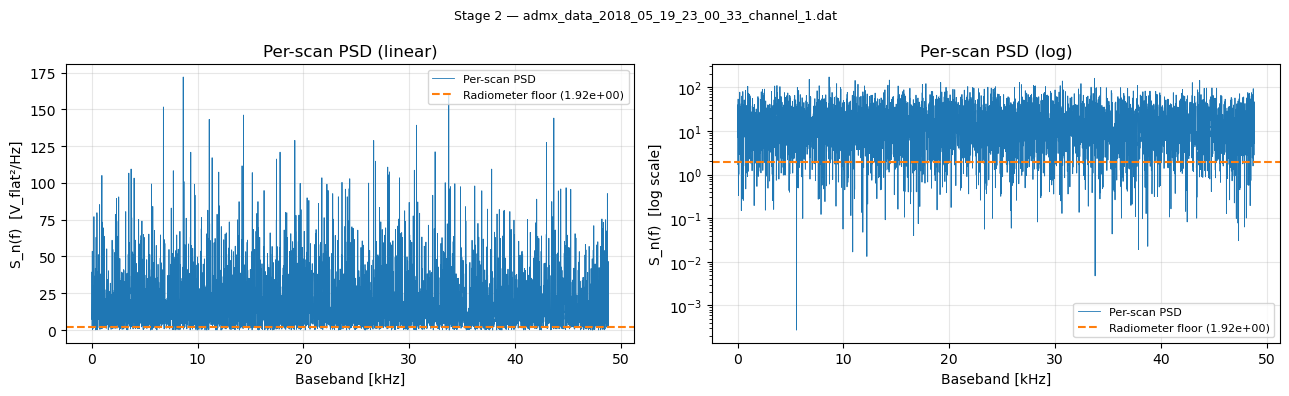

σ ratio:    1.030
Cut reason: ""
PSD range:  7.594e-06 – 3.187e+02
Saved: hr_data/prepared/admx_data_2018_05_19_23_00_33_channel_1_prepared.h5


In [8]:
from config_file_handling import find_parameter_row

binned_single   = BINNED_DIR / f'{single_dat.stem}_binned.h5'
prepared_single = PREPARED_DIR / f'{single_dat.stem}_prepared.h5'
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

row       = find_parameter_row(param_df, single_dat.name)
sp_single = ScanParameters.from_dataframe_row(row, B_FIELD)

with timer('Stage 2 — hr_raw_prep (single file)'):
    result_single = process_binned_h5(
        binned_h5_path=binned_single,
        scan_params=sp_single,
        max_stdev_ratio=3.0,
        psd_seg_len_factor=4,
    )
    if result_single is not None:
        save_prepared_scan(result_single, prepared_single)

if result_single is None:
    print('WARNING: process_binned_h5 returned None')
    print(f'  H5 exists: {binned_single.exists()}')
else:
    psd_single = result_single['psd']
    f_bb       = result_single['f_baseband']
    delta_f    = result_single['cvs'].delta_f_hz
    t_int      = sp_single.integration_time_s
    expected_floor = 2.0 / (t_int * delta_f) if (t_int > 0 and delta_f > 0) else None

    STRIDE = max(1, len(f_bb) // 5000)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Stage 2 — {single_dat.name}', fontsize=9)

    # PSD linear
    ax = axes[0]
    ax.plot(f_bb[::STRIDE] / 1e3, psd_single[::STRIDE], lw=0.6, label='Per-scan PSD')
    if expected_floor:
        ax.axhline(expected_floor, ls='--', color='C1',
                   label=f'Radiometer floor ({expected_floor:.2e})')
    ax.set_xlabel('Baseband [kHz]')
    ax.set_ylabel('S_n(f)  [V_flat²/Hz]')
    ax.set_title('Per-scan PSD (linear)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # PSD log
    ax = axes[1]
    ax.semilogy(f_bb[::STRIDE] / 1e3, psd_single[::STRIDE], lw=0.6, label='Per-scan PSD')
    if expected_floor:
        ax.axhline(expected_floor, ls='--', color='C1',
                   label=f'Radiometer floor ({expected_floor:.2e})')
    ax.set_xlabel('Baseband [kHz]')
    ax.set_ylabel('S_n(f)  [log scale]')
    ax.set_title('Per-scan PSD (log)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'σ ratio:    {result_single["stdev_ratio"]:.3f}')
    print(f'Cut reason: "{result_single["cut_reason"]}"')
    print(f'PSD range:  {psd_single.min():.3e} – {psd_single.max():.3e}')
    print(f'Saved: {prepared_single}')

=== V_flat characterization ===
Shape:        (4678096,)
Mean |V|:     2.8048e-01
Std  |V|:     1.4736e-01
Ratio std/mean (Rayleigh noise → ~0.52): 0.525

f0 baseband:  24417.8 Hz  (idx=2339408)
Linewidth:    18653.6 Hz  (~1787152 bins)
Mean |V| ON resonance:   2.8318e-01
Mean |V| OFF resonance:  2.7901e-01
Ratio on/off (>1 means Lorentzian still present): 1.015


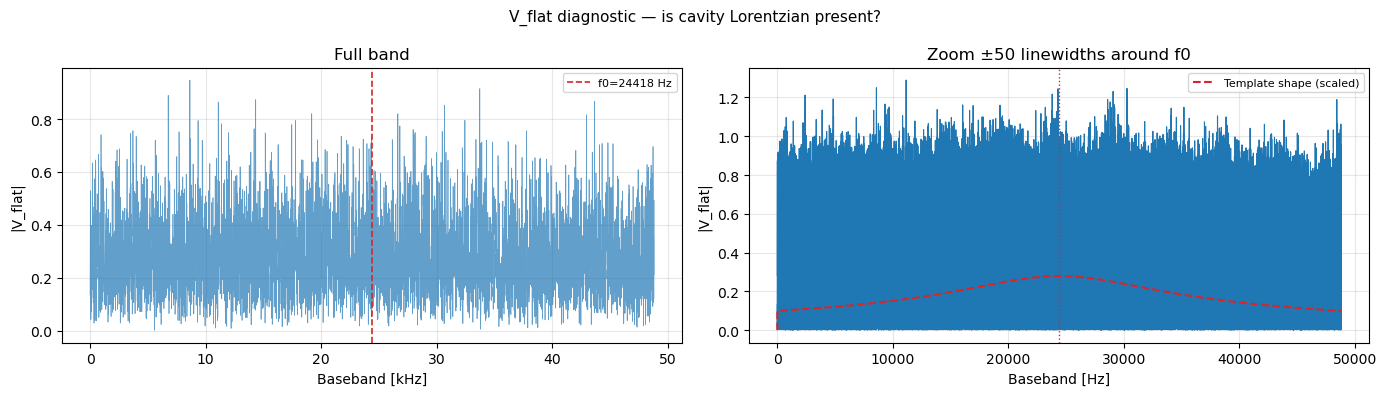

In [9]:
# ── Data diagnostic: what is V_flat and does it contain the cavity Lorentzian? ──
from pycbc.filter import matched_filter as _pycbc_mf_diag

scan_data_diag = load_prepared_scan(sorted(PREPARED_DIR.glob('*_prepared.h5'))[0])
v_flat_diag = scan_data_diag['V_flat']
f_bb_diag   = scan_data_diag['f_baseband']
df_diag     = float(scan_data_diag['delta_f_hz'])
sp_diag     = scan_data_diag['scan_params']

print('=== V_flat characterization ===')
print(f'Shape:        {v_flat_diag.shape}')
print(f'Mean |V|:     {np.mean(np.abs(v_flat_diag)):.4e}')
print(f'Std  |V|:     {np.std(np.abs(v_flat_diag)):.4e}')
print(f'Ratio std/mean (Rayleigh noise → ~0.52): {np.std(np.abs(v_flat_diag))/np.mean(np.abs(v_flat_diag)):.3f}')

# Build the Lorentzian template this scan would use
tmpl_diag = build_superradiant_template(
    scan_params=sp_diag,
    f_baseband_hz=f_bb_diag,
    delta_f_hz=df_diag,
    f_signal_offset_hz=0.0,
)
v_tmpl = np.abs(np.asarray(tmpl_diag['pycbc_template_normed'], dtype=np.complex128))
f0_bb  = tmpl_diag['f0_baseband_hz']
bw_hz  = tmpl_diag['linewidth_hz']

# Look at |V_flat| in a narrow window around f0 vs off-resonance
f0_idx   = np.argmin(np.abs(f_bb_diag - f0_bb))
bw_bins  = max(1, int(bw_hz / df_diag))
on_mask  = np.zeros(len(f_bb_diag), dtype=bool)
on_mask[max(0, f0_idx - bw_bins) : f0_idx + bw_bins] = True
off_mask = ~on_mask & (f_bb_diag > F_LOW) & (f_bb_diag < f_bb_diag[-1] * 0.9)

v_on  = np.abs(v_flat_diag[on_mask])
v_off = np.abs(v_flat_diag[off_mask])

print(f'\nf0 baseband:  {f0_bb:.1f} Hz  (idx={f0_idx})')
print(f'Linewidth:    {bw_hz:.1f} Hz  (~{bw_bins} bins)')
print(f'Mean |V| ON resonance:   {np.mean(v_on):.4e}')
print(f'Mean |V| OFF resonance:  {np.mean(v_off):.4e}')
print(f'Ratio on/off (>1 means Lorentzian still present): {np.mean(v_on)/np.mean(v_off):.3f}')

# Plot |V_flat| zoomed around f0
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('V_flat diagnostic — is cavity Lorentzian present?', fontsize=11)

# Full band
STRIDE_D = max(1, len(f_bb_diag) // 5000)
ax = axes[0]
ax.plot(f_bb_diag[::STRIDE_D] / 1e3, np.abs(v_flat_diag[::STRIDE_D]), lw=0.5, alpha=0.7)
ax.axvline(f0_bb / 1e3, color='C3', ls='--', lw=1.2, label=f'f0={f0_bb:.0f} Hz')
ax.set_xlabel('Baseband [kHz]')
ax.set_ylabel('|V_flat|')
ax.set_title('Full band')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Zoom around f0: ±50 linewidths
zoom_hz  = 50 * bw_hz
zoom_mask = (f_bb_diag > f0_bb - zoom_hz) & (f_bb_diag < f0_bb + zoom_hz)
ax = axes[1]
ax.plot(f_bb_diag[zoom_mask], np.abs(v_flat_diag[zoom_mask]), lw=0.8)
ax.plot(f_bb_diag[zoom_mask], v_tmpl[zoom_mask] * np.mean(v_off) / (np.max(v_tmpl[zoom_mask]) + 1e-30),
        'C3--', lw=1.5, label='Template shape (scaled)')
ax.axvline(f0_bb, color='C3', ls=':', lw=1)
ax.set_xlabel('Baseband [Hz]')
ax.set_ylabel('|V_flat|')
ax.set_title(f'Zoom ±{50:.0f} linewidths around f0')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
del scan_data_diag, v_flat_diag





In [10]:
# from pycbc.filter import sigma as pycbc_sigma
# from pycbc.types import FrequencySeries
# import numpy as np

# v    = np.asarray(tmpl_single['pycbc_template_normed'], dtype=np.complex128)
# p    = np.asarray(psd_fd, dtype=np.float64)
# df   = float(psd_fd.delta_f)
# N    = len(v)
# freqs = np.arange(N) * df

# # 1. What pyCBC computes for sigma
# sig_pycbc = float(pycbc_sigma(
#     tmpl_single['pycbc_template_normed'],
#     psd=psd_fd,
#     low_frequency_cutoff=F_LOW,
#     high_frequency_cutoff=F_HIGH,
# ))

# # 2. Manual inner product over the same band
# band = (freqs >= F_LOW)
# if F_HIGH is not None:
#     band &= (freqs <= F_HIGH)

# sig_manual = float(np.sqrt(4 * df * np.sum(np.abs(v[band])**2 / np.maximum(p[band], 1e-60))))

# # 3. What the noise amplitude looks like vs what sigma expects
# # For unit SNR: sigma must equal sqrt(4*df*sum(|noise|^2/S_n))
# # Since S_n = 2*df*|noise|^2 per bin:
# # sigma_noise = sqrt(4*df * sum(|noise|^2 / (2*df*|noise|^2)))
# #             = sqrt(4*df * N_band / (2*df))
# #             = sqrt(2 * N_band)
# N_band = int(np.sum(band))
# sig_noise_expected = float(np.sqrt(2 * N_band))

# print(f'sigma (pyCBC):          {sig_pycbc:.4e}')
# print(f'sigma (manual):         {sig_manual:.4e}')
# print(f'N bins in band:         {N_band:,}')
# print(f'sqrt(2*N_band):         {sig_noise_expected:.4e}')
# print()
# print(f'PSD median (in band):   {np.median(p[band]):.4e}')
# print(f'|template|^2 median:    {np.median(np.abs(v[band])**2):.4e}')
# print(f'|template|^2 max:       {np.max(np.abs(v[band])**2):.4e}')
# print()
# # Key ratio: what does the MF normalization do to noise?
# # SNR_noise_rms = sqrt(mean(|snr|^2)) 
# # For correctly normalized MF: = 1
# # For our case: = sigma_noise_effective / sigma_template
# # where sigma_noise_effective^2 = 4*df*sum(|noise|^2/S_n)
# # Since S_n = 2*df*E[|noise|^2], and actual |noise|^2 fluctuates around E[|noise|^2]:
# # sigma_noise_effective ≈ sqrt(2 * N_band) on average
# # sigma_template = sig_manual
# # Expected Rayleigh sigma = sigma_noise_effective / sigma_template
# rayleigh_expected = sig_noise_expected / sig_manual
# print(f'Expected Rayleigh sigma from first principles: {rayleigh_expected:.3f}')
# print(f'Observed Rayleigh sigma (from results):        5.3')
# print()
# print(f'If Rayleigh sigma = 5.3 and expected = {rayleigh_expected:.3f}:')
# print(f'  PSD is off by factor: {(5.3/rayleigh_expected)**2:.2f}x')
# print(f'  (positive = PSD too small, negative = too large)')

In [11]:
# psd_arr = np.asarray(psd_fd.numpy(), dtype=np.float64)
# v_arr   = np.asarray(tmpl_single['pycbc_template'].numpy(), dtype=np.complex128)

# print(f"PSD median:         {np.median(psd_arr[psd_arr>0]):.4e}")
# print(f"max|V_template|²:   {np.max(np.abs(v_arr)**2):.4e}")

# df = float(psd_fd.delta_f)
# freqs = np.arange(len(v_arr)) * df
# band = (freqs >= 50) & (freqs <= 48000)
# ratio = np.abs(v_arr[band])**2 / psd_arr[band]
# print(f"In-band |V|²/PSD median: {np.median(ratio[ratio>0]):.4e}")
# print(f"sigma check: {np.sqrt(4*df*np.sum(ratio)):.4e}")

# psd_arr = np.asarray(psd_fd.numpy(), dtype=np.float64)
# df = float(psd_fd.delta_f)

# # What noise amplitude does the PSD imply?
# std_per_bin = np.sqrt(psd_arr / (4.0 * df))
# print(f"Noise std per bin (median): {np.median(std_per_bin):.4e}")

# # What signal amplitude does the injection add?
# v_arr = np.asarray(tmpl_single['pycbc_template'].numpy(), dtype=np.complex128)
# freqs = np.arange(len(v_arr)) * df
# band = (freqs >= 50) & (freqs <= 48000)
# sigma_check = np.sqrt(4*df*np.sum(np.abs(v_arr[band])**2 / psd_arr[band]))
# scale_factor = 10.0 / sigma_check
# signal_amp = scale_factor * np.max(np.abs(v_arr))
# print(f"sigma:              {sigma_check:.4e}")
# print(f"scale_factor:       {scale_factor:.4e}")
# print(f"Signal amplitude:   {signal_amp:.4e}")
# print(f"Noise amplitude:    {np.median(std_per_bin):.4e}")
# print(f"Signal/Noise ratio in time domain: {signal_amp/np.median(std_per_bin):.4e}")

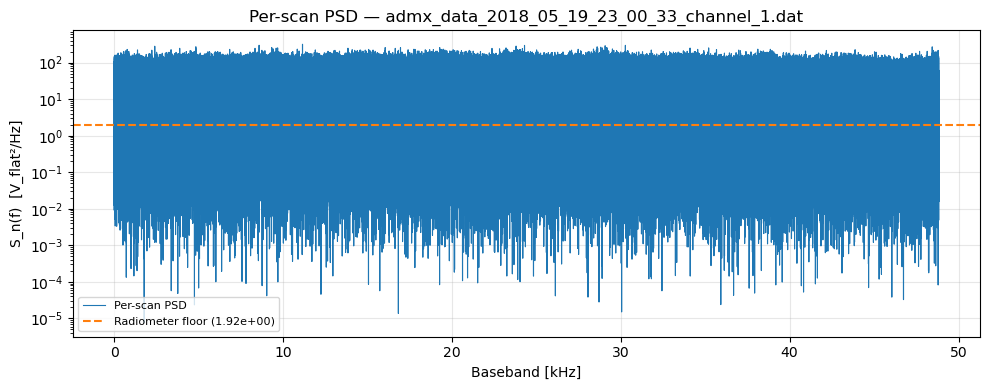

In [12]:
# Plot per-scan PSD
if result_single is not None:
    psd_single = result_single['psd']
    f_bb       = result_single['f_baseband']
    delta_f    = result_single['cvs'].delta_f_hz
    t_int      = sp_single.integration_time_s
    expected_floor = 2.0 / (t_int * delta_f) if (t_int > 0 and delta_f > 0) else None

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(f_bb / 1e3, psd_single, lw=0.8, label='Per-scan PSD')
    if expected_floor:
        ax.axhline(expected_floor, ls='--', color='C1',
                   label=f'Radiometer floor ({expected_floor:.2e})')
    ax.set_xlabel('Baseband [kHz]')
    ax.set_ylabel('S_n(f)  [V_flat²/Hz]')
    ax.set_title(f'Per-scan PSD — {single_dat.name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 1.4  Stage 3 — Waveform template

In [13]:
# Old binary merger template
# with timer('Stage 3 — build voltage template (single file)'):
#     tmpl_single = build_template_for_scan(
#         prepared_h5=prepared_single,
#         approximant=APPROXIMANT,
#         mass1=MASS_GRID[0][0],
#         mass2=MASS_GRID[0][1],
#         apply_cavity=True,
#         complex_cavity=True,
#     )
# New SR boson annihilation template


# tone_fd = tmpl_sr['pycbc_template']
#     print(f'Template sigma:  {sigma:.4e}')
#     print(f'Peak |SNR|:      {peak["snr_peak"]:.4f}')
#     print(f'Peak time:       {peak["t_peak_sec"]:.4f} s')

# if tmpl_single is not None:
#     sp = tmpl_single['scan_params']
#     scale_at_f0 = np.interp(sp.f0_hz, tmpl_single['f_abs_hz'], tmpl_single['scale'])
#     print(f'Template max |V|:     {np.max(np.abs(tmpl_single["V_template"])):.3e} V')
#     print(f'Berlin scale at f0:   {scale_at_f0:.3e} V/strain')
#     plot_template(tmpl_single, title=single_dat.stem, show=True)
# print(tmpl_single)

### 1.5  Stage 4 — Matched filter (single file, single template)
Uses stacked PSD if created, otherwise single PSD from above cells



▶  Stage 3 — cross-scan PSD stacking …


2026-05-14 12:06:27,497 INFO psd_computation: PSD: 25 scans used, 0 skipped, delta_f=0.0104 Hz, method=median
2026-05-14 12:06:27,669 INFO psd_computation: Saved PSD -> hr_data/prepared/run1b_nibble5_psd.h5
2026-05-14 12:06:27,728 INFO psd_computation: PSD stats: median=2.086e-03  min=2.456e-04  max=7.202e+03  n_used=25


✓  Stage 3 — cross-scan PSD stacking  →  6.12s
Stacked PSD: 25 scans  df=0.010438 Hz
PSD range:   2.456e-04 – 7.202e+03
PSD median:  2.086e-03

PSD self-check (ratio should be ~1): 1.005


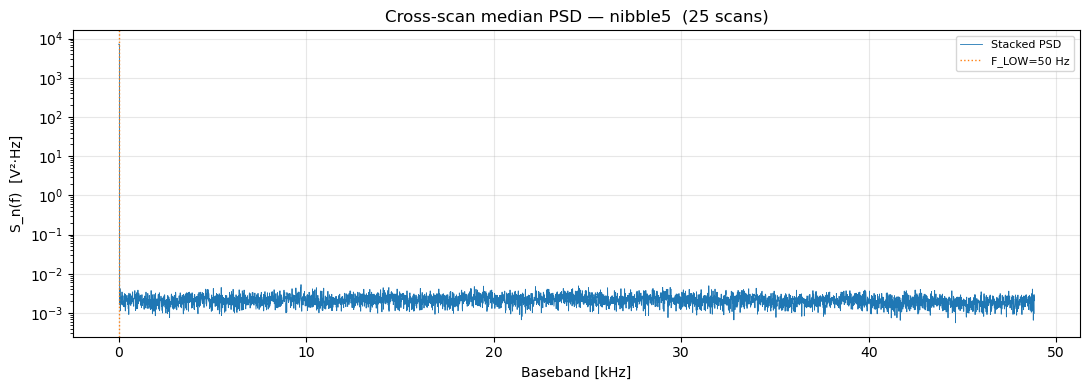


Template:  f0=24417.8 Hz  linewidth=18653.6 Hz  scale_at_f0=1.935e+10 V/strain

▶  Stage 4 — single-scan matched filter …
✓  Stage 4 — single-scan matched filter  →  1.00s
Peak SNR:       6.195  at t=65.531s
Rayleigh sigma: 1.032  (expected ~1.0)


In [14]:
# ── Stage 3: Load stacked PSD + build template + run matched filter ───────────
from psd_computation import load_psd_h5
from pycbc.types import FrequencySeries

psd_out_h5 = PREPARED_DIR / f"{nibble['file_prefix']}_psd.h5"
psd_out_h5.unlink(missing_ok=True)

with timer('Stage 3 — cross-scan PSD stacking'):
    psd_fd, f_bb_psd, f_abs_psd = run_psd_computation(
        run_definition_path=RUN_DEFINITION,
        nibble_name=NIBBLE_NAME,
        prepared_dir=str(PREPARED_DIR),
        output_path=str(psd_out_h5),
        stack_method='median',
        f_low_hz=F_LOW,
        f_high_hz=F_HIGH,
        validate=True,
        plot=False,
    )

_, _, _, psd_meta = load_psd_h5(psd_out_h5)
psd_arr = np.asarray(psd_fd, dtype=np.float64)
df_psd  = float(psd_fd.delta_f)

print(f'Stacked PSD: {psd_meta["n_scans_used"]} scans  df={df_psd:.6f} Hz')
print(f'PSD range:   {psd_arr.min():.3e} – {psd_arr.max():.3e}')
print(f'PSD median:  {np.median(psd_arr):.3e}')

# ── PSD self-check: median PSD should satisfy S_n = 2·df·E[|V_flat|²] ────────
_s0 = load_prepared_scan(sorted(PREPARED_DIR.glob('*_prepared.h5'))[0])
_expected_var = np.median(psd_arr) / (2.0 * df_psd)
_actual_var   = float(np.mean(np.abs(_s0['V_flat'])**2))
print(f'\nPSD self-check (ratio should be ~1): {_actual_var / _expected_var:.3f}')
del _s0

# ── Plot stacked PSD ─────────────────────────────────────────────────────────
STRIDE = max(1, len(f_bb_psd) // 5000)
fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogy(f_bb_psd[::STRIDE] / 1e3, psd_arr[::STRIDE], lw=0.6, label='Stacked PSD')
ax.axvline(F_LOW / 1e3, ls=':', color='C1', lw=1, label=f'F_LOW={F_LOW:.0f} Hz')
ax.set_xlabel('Baseband [kHz]')
ax.set_ylabel('S_n(f)  [V²·Hz]')
ax.set_title(f'Cross-scan median PSD — {NIBBLE_NAME}  ({psd_meta["n_scans_used"]} scans)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'stacked_psd.png', dpi=150)
plt.show()

# ── Build template + run single-scan matched filter ───────────────────────────
# Load the single scan data — use V_flat directly, not cvs
scan_single = load_prepared_scan(prepared_single)
if scan_single is None:
    raise RuntimeError(f'Scan was cut: {prepared_single}')

v_flat_single  = scan_single['V_flat']
df_single      = float(scan_single['delta_f_hz'])
f_bb_single    = scan_single['f_baseband']

# Template must be built on the PSD grid (which == data grid after hr_raw_prep)
tmpl_single = build_superradiant_template(
    scan_params=sp_single,
    f_baseband_hz=f_bb_single,
    delta_f_hz=df_psd,          # use psd delta_f — must match data
    f_signal_offset_hz=0.0,
)
if tmpl_single is None:
    raise RuntimeError('Template build failed — check scan_params')

data_fd_single = FrequencySeries(v_flat_single.astype(np.complex128), delta_f=df_single)
del scan_single, v_flat_single

print(f'\nTemplate:  f0={tmpl_single["f0_baseband_hz"]:.1f} Hz  '
      f'linewidth={tmpl_single["linewidth_hz"]:.1f} Hz  '
      f'scale_at_f0={tmpl_single["scale_at_f0"]:.3e} V/strain')

with timer('Stage 4 — single-scan matched filter'):
    snr_ts, sigma_mf, peak_mf = matched_filter_single(
        data_fd=data_fd_single,
        template_fd=tmpl_single['pycbc_template_normed'],
        psd_fd=psd_fd,
        f_low=F_LOW,
        f_high=F_HIGH,
        normalize=True,
    )

del data_fd_single
gc.collect()

snr_arr_single = np.abs(snr_ts.numpy())
rayleigh_sigma = float(np.sqrt(np.mean(snr_arr_single**2) / 2.0))
print(f'Peak SNR:       {peak_mf["snr_peak"]:.3f}  at t={peak_mf["t_peak_sec"]:.3f}s')
print(f'Rayleigh sigma: {rayleigh_sigma:.3f}  (expected ~1.0)')

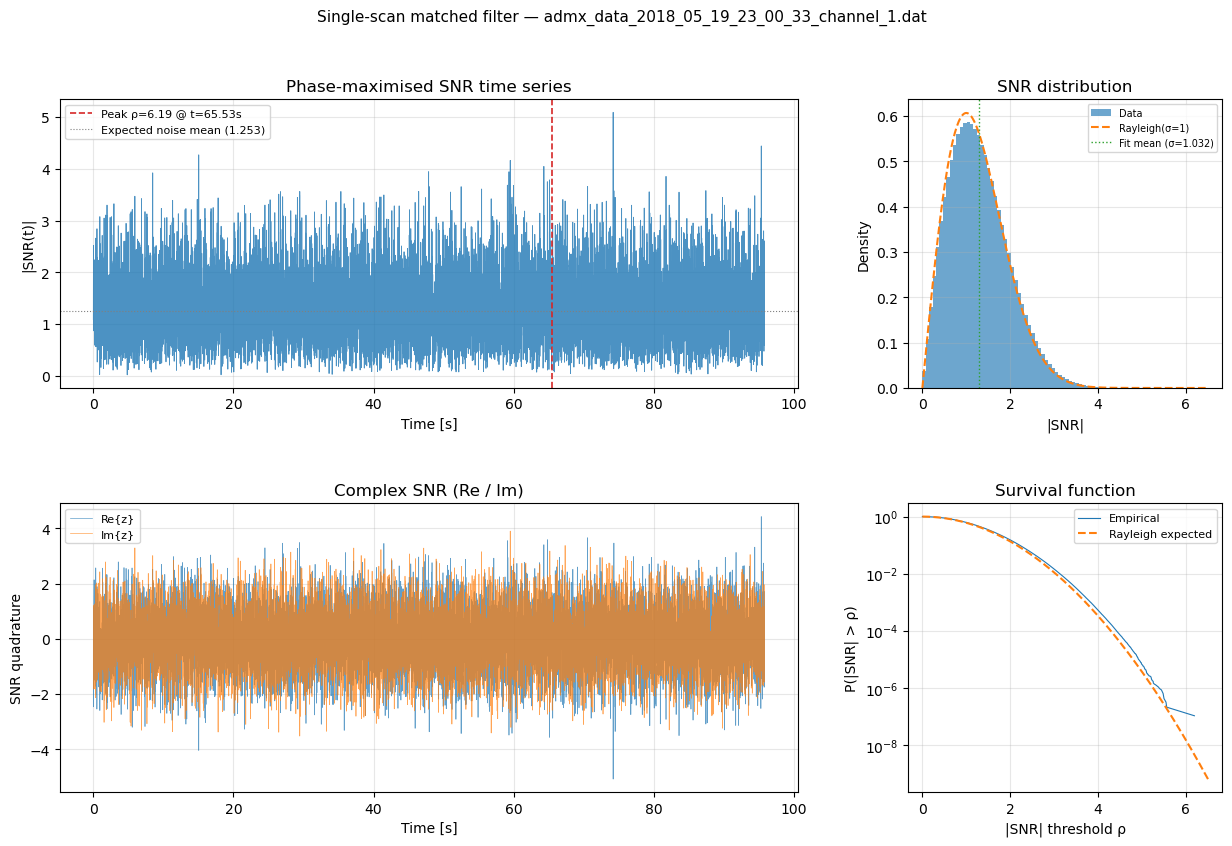

In [15]:
# ── Single-scan MF output plots ───────────────────────────────────────────────
dt_mf  = float(snr_ts.delta_t)
t_axis = np.arange(len(snr_arr_single)) * dt_mf

STRIDE_PLOT = max(1, len(snr_arr_single) // 10_000)
t_plot   = t_axis[::STRIDE_PLOT]
snr_plot = snr_arr_single[::STRIDE_PLOT]

rho_grid = np.linspace(0, max(snr_arr_single.max() * 1.05, 6.0), 300)

fig = plt.figure(figsize=(15, 9))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)
fig.suptitle(f'Single-scan matched filter — {single_dat.name}', fontsize=11)

# |SNR(t)|
ax = fig.add_subplot(gs[0, :2])
ax.plot(t_plot, snr_plot, lw=0.6, alpha=0.8)
ax.axvline(peak_mf['t_peak_sec'], ls='--', color='C3', lw=1.2,
           label=f'Peak ρ={peak_mf["snr_peak"]:.2f} @ t={peak_mf["t_peak_sec"]:.2f}s')
ax.axhline(np.sqrt(np.pi/2), ls=':', color='gray', lw=0.8,
           label=f'Expected noise mean ({np.sqrt(np.pi/2):.3f})')
ax.set_xlabel('Time [s]')
ax.set_ylabel('|SNR(t)|')
ax.set_title('Phase-maximised SNR time series')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# SNR histogram
ax = fig.add_subplot(gs[0, 2])
ax.hist(snr_arr_single, bins=80, density=True, alpha=0.65, label='Data')
ax.plot(rho_grid, rho_grid * np.exp(-rho_grid**2 / 2), 'C1--', lw=1.5,
        label=f'Rayleigh(σ=1)')
ax.axvline(rayleigh_sigma * np.sqrt(np.pi/2), ls=':', color='C2', lw=1,
           label=f'Fit mean (σ={rayleigh_sigma:.3f})')
ax.set_xlabel('|SNR|')
ax.set_ylabel('Density')
ax.set_title('SNR distribution')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Complex quadratures
snr_complex = snr_ts.numpy()[::STRIDE_PLOT]
ax = fig.add_subplot(gs[1, :2])
ax.plot(t_plot, np.real(snr_complex), lw=0.5, alpha=0.7, label='Re{z}')
ax.plot(t_plot, np.imag(snr_complex), lw=0.5, alpha=0.7, label='Im{z}')
ax.set_xlabel('Time [s]')
ax.set_ylabel('SNR quadrature')
ax.set_title('Complex SNR (Re / Im)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Survival function
ax = fig.add_subplot(gs[1, 2])
sorted_snr = np.sort(snr_arr_single)[::-1]
ax.semilogy(sorted_snr, np.arange(1, len(sorted_snr)+1) / len(sorted_snr),
            lw=0.8, label='Empirical')
ax.semilogy(rho_grid, np.exp(-rho_grid**2 / 2), 'C1--', lw=1.5,
            label='Rayleigh expected')
ax.set_xlabel('|SNR| threshold ρ')
ax.set_ylabel('P(|SNR| > ρ)')
ax.set_title('Survival function')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.savefig(RESULTS_DIR / 'single_scan_mf.png', dpi=150)
plt.show()
del snr_plot, snr_complex

### 1.6  Stage 5 — Synthetic injection recovery test
Injects a signal at known SNR and verifies the filter recovers it correctly.


▶  Synthetic injection + recovery …
✓  Synthetic injection + recovery  →  1.34s
Target SNR:        10.0
Template sigma:    6.6638e+03
Recovered peak:    9.807  at t=50.000s
Recovery ratio:    0.981  (expected ~1.0)
Noise Rayleigh σ:  1.000  (expected ~1.0)
KS p-value:        0.0547  (>0.05 = consistent with Gaussian noise)


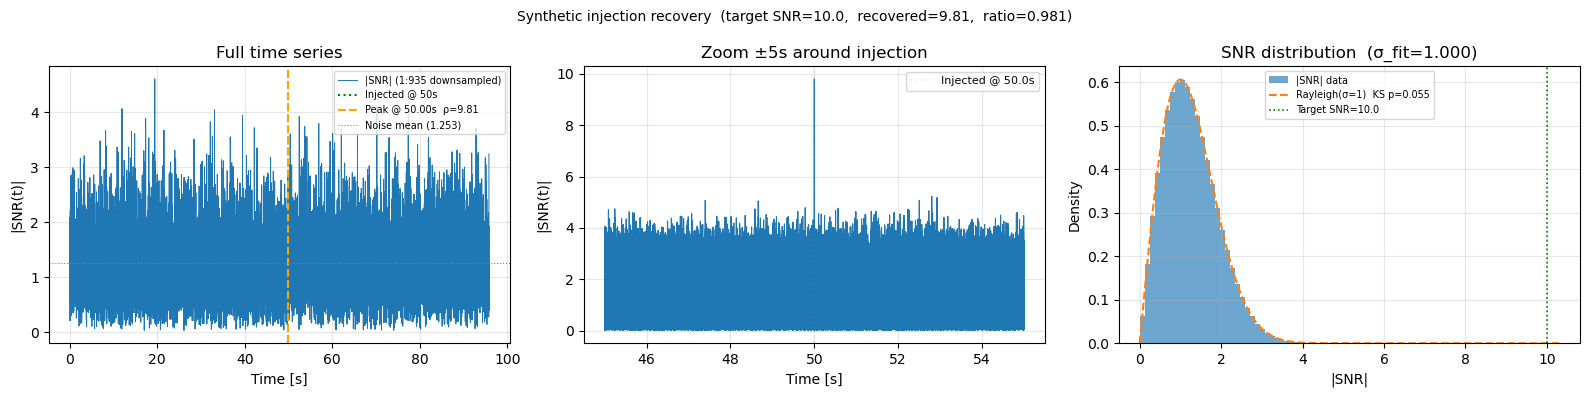

In [37]:
# ── Synthetic injection: recover known SNR ────────────────────────────────────
from scipy import stats

TARGET_INJ_SNR = 10.0
T_INJECT       = 50.0
SEED           = 42

with timer('Synthetic injection + recovery'):
    data_inj_fd, noise_fd, signal_fd, psd_used, inj_info = make_synthetic_injection(
        template_fd=tmpl_single['pycbc_template_normed'],
        psd_fd=psd_fd,
        target_snr=TARGET_INJ_SNR,
        t_inject_sec=T_INJECT,
        f_low=F_LOW,
        f_high=F_HIGH,
        seed=SEED,
    )
    snr_inj, sigma_inj, peak_inj = matched_filter_single(
        data_fd=data_inj_fd,
        template_fd=tmpl_single['pycbc_template_normed'],
        psd_fd=psd_used,
        f_low=F_LOW,
        f_high=F_HIGH,
        normalize=True,
    )

snr_inj_arr = np.abs(snr_inj.numpy())
dt_inj      = float(snr_inj.delta_t)
t_inj_axis  = np.arange(len(snr_inj_arr)) * dt_inj
rayleigh_inj = float(np.sqrt(np.mean(snr_inj_arr**2) / 2.0))
recovery     = peak_inj['snr_peak'] / TARGET_INJ_SNR

del data_inj_fd, noise_fd, signal_fd, psd_used
gc.collect()

print(f'Target SNR:        {TARGET_INJ_SNR:.1f}')
print(f'Template sigma:    {inj_info["sigma"]:.4e}')
print(f'Recovered peak:    {peak_inj["snr_peak"]:.3f}  at t={peak_inj["t_peak_sec"]:.3f}s')
print(f'Recovery ratio:    {recovery:.3f}  (expected ~1.0)')
print(f'Noise Rayleigh σ:  {rayleigh_inj:.3f}  (expected ~1.0)')
ks_stat, ks_p = stats.kstest(snr_inj_arr, lambda x: 1.0 - np.exp(-x**2 / 2.0))
print(f'KS p-value:        {ks_p:.4f}  (>0.05 = consistent with Gaussian noise)')

# ── Plots ─────────────────────────────────────────────────────────────────────
STRIDE_INJ = max(1, len(snr_inj_arr) // 10_000)
t_plot_inj  = t_inj_axis[::STRIDE_INJ]
snr_plot_inj = snr_inj_arr[::STRIDE_INJ]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Synthetic injection recovery  (target SNR={TARGET_INJ_SNR},  '
             f'recovered={peak_inj["snr_peak"]:.2f},  ratio={recovery:.3f})', fontsize=10)

# Full time series
ax = axes[0]
ax.plot(t_plot_inj, snr_plot_inj, lw=0.7,
        label=f'|SNR| (1:{STRIDE_INJ} downsampled)')
ax.axvline(T_INJECT, color='green', ls=':', lw=1.5, label=f'Injected @ {T_INJECT:.0f}s')
ax.axvline(peak_inj['t_peak_sec'], color='orange', ls='--', lw=1.5,
           label=f'Peak @ {peak_inj["t_peak_sec"]:.2f}s  ρ={peak_inj["snr_peak"]:.2f}')
ax.axhline(np.sqrt(np.pi/2), color='gray', ls=':', lw=0.8,
           label=f'Noise mean ({np.sqrt(np.pi/2):.3f})')
ax.set_xlabel('Time [s]')
ax.set_ylabel('|SNR(t)|')
ax.set_title('Full time series')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Zoom around injection
ax = axes[1]
win = 5.0
mask = (t_inj_axis >= T_INJECT - win) & (t_inj_axis <= T_INJECT + win)
ax.plot(t_inj_axis[mask], snr_inj_arr[mask], lw=0.8)
ax.axvline(T_INJECT, color='green', ls=':', lw=1.5, alpha = 0.1, label=f'Injected @ {T_INJECT}s')
# ax.axvline(peak_inj['t_peak_sec'], color='orange', ls='--', lw=1.5, label='Peak')
ax.set_xlabel('Time [s]')
ax.set_ylabel('|SNR(t)|')
ax.set_title(f'Zoom ±{win:.0f}s around injection')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Noise distribution
rho_grid = np.linspace(0, max(snr_inj_arr.max() * 1.05, 6.0), 300)
ax = axes[2]
ax.hist(snr_inj_arr, bins=80, density=True, alpha=0.65, label='|SNR| data')
ax.plot(rho_grid, rho_grid * np.exp(-rho_grid**2 / 2), 'C1--', lw=1.5,
        label=f'Rayleigh(σ=1)  KS p={ks_p:.3f}')
ax.axvline(TARGET_INJ_SNR, color='green', ls=':', lw=1.2,
           label=f'Target SNR={TARGET_INJ_SNR}')
ax.set_xlabel('|SNR|')
ax.set_ylabel('Density')
ax.set_title(f'SNR distribution  (σ_fit={rayleigh_inj:.3f})')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'injection_recovery.png', dpi=150)
plt.show()



In [17]:
# ── Superradiant template diagnostics ────────────────────────────────────
psd_arr    = np.asarray(psd_fd.numpy(), dtype=np.float64)
v_arr      = np.asarray(tmpl_single['pycbc_template_normed'].numpy(), dtype=np.complex128)
df         = float(psd_fd.delta_f)
freqs_bb   = np.arange(len(v_arr)) * df
band       = (freqs_bb >= F_LOW) & (freqs_bb <= 48_000.0)

scale_at_f0   = tmpl_single['scale_at_f0']
linewidth_hz  = tmpl_single['linewidth_hz']
tau_ring_s    = tmpl_single['tau_ring_s']
f0_bb         = tmpl_single['f0_baseband_hz']
sigma_sr      = np.sqrt(4 * df * np.sum(np.abs(v_arr[band])**2 /
                        np.maximum(psd_arr[band], 1e-60)))
h0_at_snr5    = 5.0 / scale_at_f0

print(f'scale_at_f0:      {scale_at_f0:.4e}  V/strain')
print(f'sigma:            {sigma_sr:.4e}')
print(f'linewidth f0/Q:   {linewidth_hz:.1f} Hz  (~18 kHz expected)')
print(f'tau_ring:         {tau_ring_s*1e6:.2f} us  (<< 100 s scan)')
print(f'f0_baseband:      {f0_bb:.2f} Hz')
print(f'h0 at SNR=5:      {h0_at_snr5:.4e} strain')
print(f'PSD median:       {np.median(psd_arr[psd_arr>0]):.4e}  V²/Hz')
print(f'max|V_template|:  {np.max(np.abs(v_arr)):.4e}  V/strain')

scale_at_f0:      1.9352e+10  V/strain
sigma:            6.6470e+03
linewidth f0/Q:   18653.6 Hz  (~18 kHz expected)
tau_ring:         17.06 us  (<< 100 s scan)
f0_baseband:      24417.83 Hz
h0 at SNR=5:      2.5837e-10 strain
PSD median:       2.0860e-03  V²/Hz
max|V_template|:  1.0000e+00  V/strain


Rayleigh σ_fit: 0.9996  (expected 1.0 for unit-normalized noise)
KS test p-value: 0.9164  (PASS — consistent with Gaussian)
N samples:       9,356,190
FAR threshold:   ρ > 5.666  (1 expected false alarm)
Gaussian equiv:  7.34σ

Candidates above threshold: 8
  t=34.403s  ρ=6.058  p=1.076e-08
  t=34.403s  ρ=5.903  p=2.706e-08
  t=36.469s  ρ=5.729  p=7.463e-08
  t=41.778s  ρ=5.823  p=4.324e-08
  t=50.000s  ρ=6.090  p=8.849e-09
  t=50.000s  ρ=9.807  p=1.306e-21
  t=50.000s  ρ=8.882  p=7.405e-18
  t=70.281s  ρ=5.789  p=5.276e-08


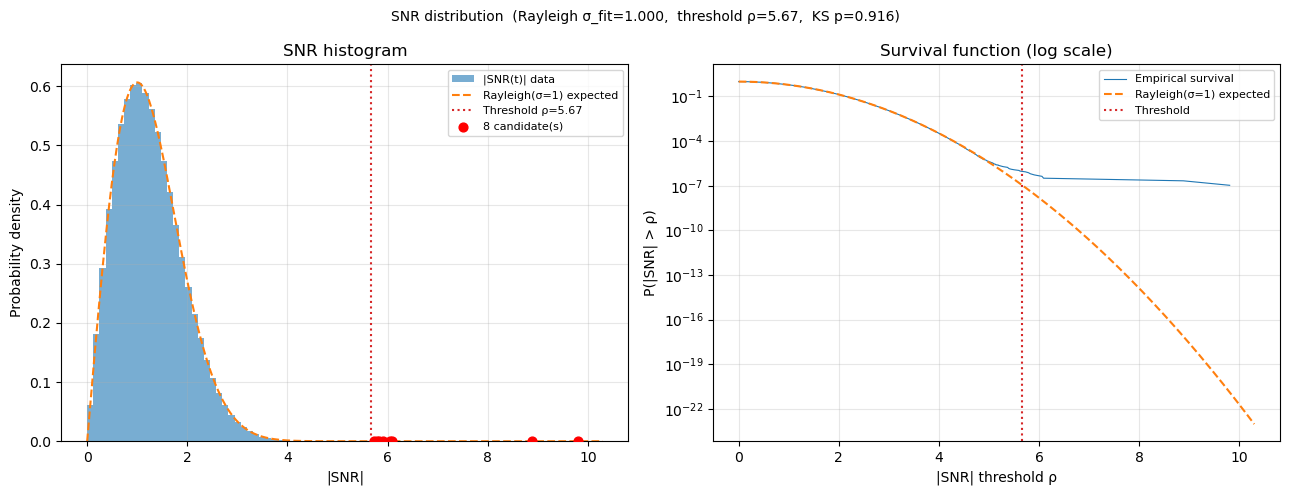

23737

In [18]:
from scipy import stats
from scipy.special import ndtri

snr_arr = np.abs(snr_inj.numpy())  # or snr_ts.numpy() for the real data

# ── 1. Fit Rayleigh distribution to the bulk ──────────────────────────────
# Under Gaussian noise, |z(t)| ~ Rayleigh(σ=1) after normalization
# MLE for Rayleigh σ: σ_fit = sqrt(mean(|z|²) / 2)
rayleigh_sigma_fit = float(np.sqrt(np.mean(snr_arr**2) / 2.0))
print(f"Rayleigh σ_fit: {rayleigh_sigma_fit:.4f}  (expected 1.0 for unit-normalized noise)")

# ── 2. KS test against Rayleigh(σ=1) ─────────────────────────────────────
ks_stat, ks_pval = stats.kstest(
    snr_arr / rayleigh_sigma_fit,
    lambda x: 1.0 - np.exp(-x**2 / 2.0)
)
print(f"KS test p-value: {ks_pval:.4f}  ({'PASS — consistent with Gaussian' if ks_pval > 0.05 else 'FAIL — non-Gaussian noise'})")

# ── 3. Detection threshold ────────────────────────────────────────────────
# Set threshold so expected false alarms = 1 across the scan
N_samples = len(snr_arr)
p_fa = 1.0 / N_samples
rho_thresh = float(np.sqrt(-2.0 * np.log(p_fa)))
print(f"N samples:       {N_samples:,}")
print(f"FAR threshold:   ρ > {rho_thresh:.3f}  (1 expected false alarm)")

# Gaussian-equivalent significance of threshold
# P(Rayleigh > ρ) = exp(-ρ²/2) → Gaussian equiv = sqrt(2)*erfinv(1 - 2*exp(-ρ²/2))
gaussian_equiv = float(np.sqrt(2) * np.abs(ndtri(1 - np.exp(-rho_thresh**2 / 2))))
print(f"Gaussian equiv:  {gaussian_equiv:.2f}σ")

# ── 4. Candidates ─────────────────────────────────────────────────────────
candidate_mask = snr_arr > rho_thresh
n_candidates = int(np.sum(candidate_mask))
candidate_times = t_axis[candidate_mask]
candidate_snrs  = snr_arr[candidate_mask]
print(f"\nCandidates above threshold: {n_candidates}")
for t_c, rho_c in zip(candidate_times[:10], candidate_snrs[:10]):
    p_val = float(np.exp(-rho_c**2 / 2.0))
    print(f"  t={t_c:.3f}s  ρ={rho_c:.3f}  p={p_val:.3e}")

# ── 5. Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"SNR distribution  (Rayleigh σ_fit={rayleigh_sigma_fit:.3f},  "
             f"threshold ρ={rho_thresh:.2f},  KS p={ks_pval:.3f})", fontsize=10)

rho_max  = max(snr_arr.max() * 1.05, rho_thresh * 1.3)
rho_grid = np.linspace(0, rho_max, 400)

# Histogram vs expected Rayleigh
ax = axes[0]
ax.hist(snr_arr, bins=80, density=True, alpha=0.6, label='|SNR(t)| data')
rayleigh_pdf = rho_grid * np.exp(-rho_grid**2 / 2.0)
ax.plot(rho_grid, rayleigh_pdf, 'C1--', lw=1.5, label='Rayleigh(σ=1) expected')
ax.axvline(rho_thresh, color='C3', lw=1.5, ls=':', label=f'Threshold ρ={rho_thresh:.2f}')
if n_candidates:
    ax.scatter(candidate_snrs, np.zeros(n_candidates),
               color='red', zorder=5, s=40, label=f'{n_candidates} candidate(s)')
ax.set_xlabel('|SNR|')
ax.set_ylabel('Probability density')
ax.set_title('SNR histogram')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Survival function (log scale)
ax = axes[1]
sorted_snr = np.sort(snr_arr)[::-1]
ecdf_y = np.arange(1, len(sorted_snr)+1) / len(sorted_snr)
ax.semilogy(sorted_snr, ecdf_y, lw=0.8, label='Empirical survival')
ax.semilogy(rho_grid, np.exp(-rho_grid**2 / 2.0), 'C1--', lw=1.5,
            label='Rayleigh(σ=1) expected')
ax.axvline(rho_thresh, color='C3', lw=1.5, ls=':', label=f'Threshold')
ax.set_xlabel('|SNR| threshold ρ')
ax.set_ylabel('P(|SNR| > ρ)')
ax.set_title('Survival function (log scale)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'snr_distribution.png', dpi=150)
plt.show()

del snr_inj, snr_inj_arr, t_plot_inj, snr_plot_inj
gc.collect()

<!-- <!-- --- -->
# Section 2 — Full nibble pipeline
Processes all `.dat` files for `NIBBLE_NAME`, builds a stacked PSD, runs the matched-filter bank over every scan, and produces strain limits. -->

In [19]:
_timers.clear()

N bins: 4,678,096   Δf = 0.010438 Hz
f_abs:  739.9802 – 740.0290 MHz


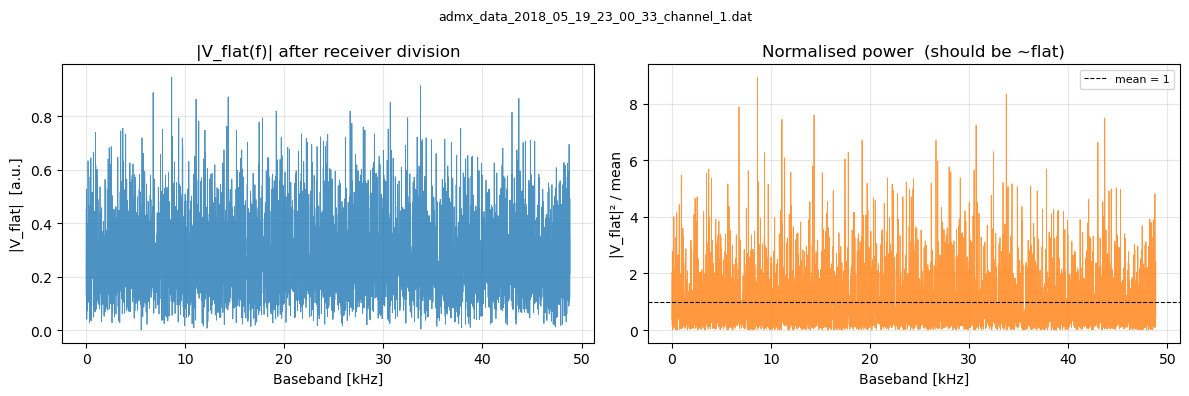

In [20]:
if result is None:
    print("process_scan returned None — check find_parameter_row")
else:
    cvs_single, receiver_shape, freqs = result
    print(f'N bins: {len(cvs_single):,}   Δf = {cvs_single.delta_f_hz:.6f} Hz')
    print(f'f_abs:  {cvs_single.f_abs_hz[0]/1e6:.4f} – {cvs_single.f_abs_hz[-1]/1e6:.4f} MHz')

    STRIDE = max(1, len(cvs_single) // 5000)
    f_khz  = cvs_single.f_baseband_hz[::STRIDE] / 1e3
    vf     = np.abs(cvs_single.yvalues[::STRIDE])
    power  = np.abs(cvs_single.yvalues) ** 2

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Flattened voltage amplitude
    axes[0].plot(f_khz, vf, lw=0.6, alpha=0.8)
    axes[0].set_title('|V_flat(f)| after receiver division')
    axes[0].set_xlabel('Baseband [kHz]')
    axes[0].set_ylabel('|V_flat|  [a.u.]')
    axes[0].grid(True, alpha=0.3)

    # Normalised power — should be ~flat at 1
    axes[1].plot(f_khz, power[::STRIDE] / np.mean(power), lw=0.6, alpha=0.8, color='C1')
    axes[1].axhline(1.0, ls='--', lw=0.8, color='k', label='mean = 1')
    axes[1].set_title('Normalised power  (should be ~flat)')
    axes[1].set_xlabel('Baseband [kHz]')
    axes[1].set_ylabel('|V_flat|² / mean')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'{single_dat.name}', fontsize=9)
    plt.tight_layout()
    plt.show()

### 2.1  Stage 1 — binned4: full nibble

In [21]:
skip = True
if skip:
    print("Skipped, flattened voltage files already exist")
    timer(f'Stage 1 — skipped')
else:
        
    with timer(f'Stage 1 — binned4 (full nibble: {len(all_dat)} files)'):
        BINNED_DIR.mkdir(parents=True, exist_ok=True)
        outputs_binned = binned_run_pipeline(
            run_definition_path=RUN_DEFINITION,
            nibble_name=NIBBLE_NAME,
            hr_root=HR_ROOT,
            param_date=PARAM_DATE,
            output_subfolder='binned_hr_data',
            seg_len=SEG_LEN,
            crop_seconds=CROP_SECONDS,
            window=WINDOW,
            channel=CHANNEL,
            overwrite=True,
        )

    print(f'Binned files written: {len(outputs_binned)}')

Skipped, flattened voltage files already exist


### 2.2  Stage 2 — hr_raw_prep: full nibble

In [22]:
skip = False
if skip:
    print("Skipped, hr_raw_prep files already exist")
    timer(f'Stage 2 — skipped')
else:

    with timer(f'Stage 2 — hr_raw_prep (full nibble)'):
        prepared_files = run_hr_raw_prep(
            run_definition_path=RUN_DEFINITION,
            nibble_name=NIBBLE_NAME,
            param_date=PARAM_DATE,
            binned_dir=str(BINNED_DIR),
            output_dir=str(PREPARED_DIR),
            max_stdev_ratio=3.0,
            psd_seg_len_factor=4,
            overwrite=True,
        )

    if not prepared_files:
        print('WARNING: no prepared files — check binned_dir has *_binned.h5 files')
    else:
        n_cut = sum(1 for p in prepared_files if load_prepared_scan(p) is None)
        print(f'Prepared: {len(prepared_files)}  |  cut: {n_cut}  |  usable: {len(prepared_files)-n_cut}')


▶  Stage 2 — hr_raw_prep (full nibble) …


2026-05-14 12:06:48,306 INFO hr_raw_prep: hr_raw_prep: nibble=nibble5, 1 binned files, max_stdev_ratio=3.0
2026-05-14 12:06:48,701 INFO hr_raw_prep: Saved admx_data_2018_05_19_23_00_33_channel_1_prepared.h5  (σ_ratio=1.03)
2026-05-14 12:06:48,701 INFO hr_raw_prep: hr_raw_prep done: 1 / 1 files written, 0 cut


✓  Stage 2 — hr_raw_prep (full nibble)  →  0.43s
Prepared: 1  |  cut: 0  |  usable: 1


### 2.3  Stage 3 — PSD stacking

In [23]:
psd_out_h5.unlink(missing_ok=True)
print('Deleted stale PSD')

Deleted stale PSD



▶  Stage 3 — psd_computation (cross-scan stacking) …


2026-05-14 12:06:54,783 INFO psd_computation: PSD: 25 scans used, 0 skipped, delta_f=0.0104 Hz, method=median
2026-05-14 12:06:54,933 INFO psd_computation: Saved PSD -> hr_data/prepared/run1b_nibble5_psd.h5
2026-05-14 12:06:54,991 INFO psd_computation: PSD stats: median=2.086e-03  min=2.456e-04  max=7.202e+03  n_used=25
/var/folders/__/68q69_j51cj16zb24xlwg1kw0000gn/T/ipykernel_84572/3816292356.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  psd_arr = np.array(psd_fd)


✓  Stage 3 — psd_computation (cross-scan stacking)  →  6.19s
PSD bins:        4,678,096  |  Δf = 0.010438 Hz
PSD range:       2.456e-04 – 7.202e+03 V²/Hz
PSD median:      2.085e-03 V²/Hz
DC spike ends:   50.0 Hz  (current F_LOW = 50.0 Hz)


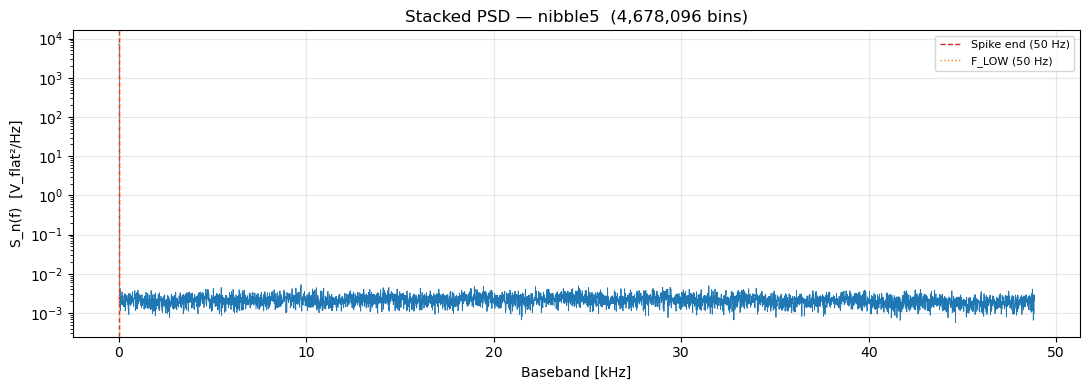

In [24]:
psd_out_h5 = PREPARED_DIR / f"{nibble['file_prefix']}_psd.h5"
psd_out_h5.unlink(missing_ok=True) 

with timer('Stage 3 — psd_computation (cross-scan stacking)'):
    psd_fd, f_bb_psd, f_abs_psd = run_psd_computation(
        run_definition_path=RUN_DEFINITION,
        nibble_name=NIBBLE_NAME,
        prepared_dir=str(PREPARED_DIR),
        output_path=str(psd_out_h5),
        stack_method='median',
        f_low_hz=F_LOW,
        f_high_hz=F_HIGH,
        validate=True,
        plot=False,
    )

psd_arr = np.array(psd_fd)

# Find where the DC spike ends
f_bins        = np.arange(len(psd_arr)) * float(psd_fd.delta_f)
passband_mask = f_bins > 1000.0
median_pass   = float(np.median(psd_arr[passband_mask]))
spike_bins    = np.where(psd_arr > 10.0 * median_pass)[0]
spike_end_hz  = float(f_bins[spike_bins[-1]]) if len(spike_bins) > 0 else 0.0

print(f'PSD bins:        {len(psd_arr):,}  |  Δf = {float(psd_fd.delta_f):.6f} Hz')
print(f'PSD range:       {psd_arr.min():.3e} – {psd_arr.max():.3e} V²/Hz')
print(f'PSD median:      {median_pass:.3e} V²/Hz')
print(f'DC spike ends:   {spike_end_hz:.1f} Hz  (current F_LOW = {F_LOW:.1f} Hz)')

if spike_end_hz > F_LOW:
    print(f'WARNING: spike extends beyond F_LOW — consider setting F_LOW >= {spike_end_hz * 1.5:.0f} Hz')

STRIDE = max(1, len(f_bb_psd) // 5000)
fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogy(f_bb_psd[::STRIDE] / 1e3, psd_arr[::STRIDE], lw=0.6)
if spike_end_hz > 0:
    ax.axvline(spike_end_hz / 1e3, ls='--', color='C3', lw=1,
               label=f'Spike end ({spike_end_hz:.0f} Hz)')
ax.axvline(F_LOW / 1e3, ls=':', color='C1', lw=1,
           label=f'F_LOW ({F_LOW:.0f} Hz)')
ax.set_xlabel('Baseband [kHz]')
ax.set_ylabel('S_n(f)  [V_flat²/Hz]')
ax.set_title(f'Stacked PSD — {NIBBLE_NAME}  ({len(psd_arr):,} bins)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Note: above plot has PSD divergence at F_low because the divergence (1e6) will cause the matched filter inner product to contribute effectively zero. The apparent divergence is intentional in order to deal with the small PSD freq range.


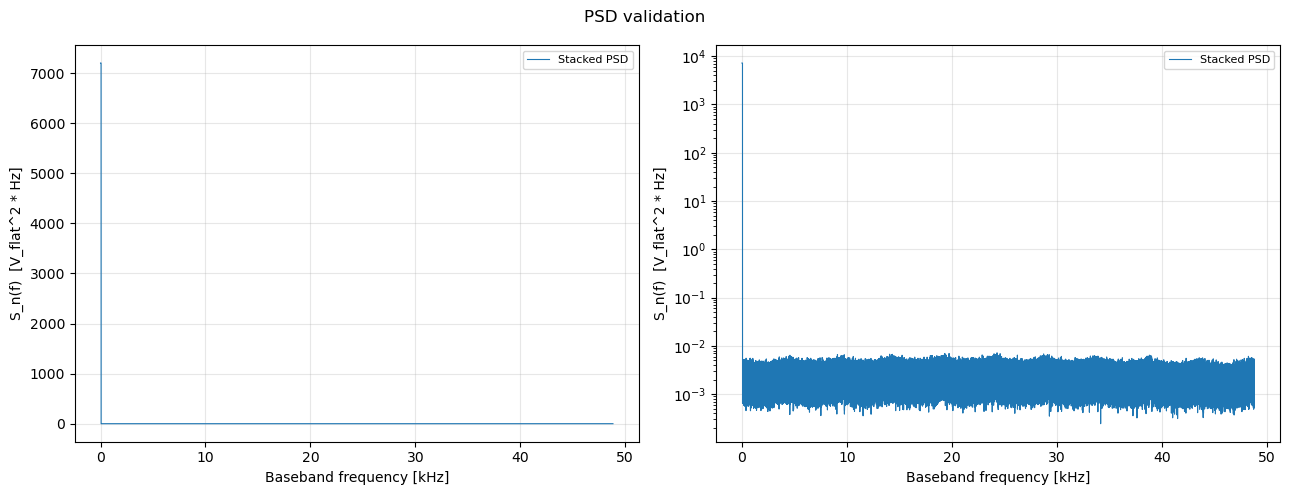

PSD validation: {'psd_median': 0.0020859954525611884, 'psd_min': 0.0002455627089824825, 'psd_max': 7202.435926946525, 'expected_floor': None, 'excess_ratio': None}


In [25]:
# Plot stacked PSD
_, _, _, psd_meta = load_psd_h5(psd_out_h5)
stats = validate_psd(psd_fd, f_bb_psd, plot=True)
print('PSD validation:', stats)

### 2.4  Stage 4+5 — Matched filter over full nibble

In [26]:
# ── Full nibble superradiant matched filter ───────────────────────────────────
from pycbc.filter import matched_filter as _pycbc_mf
from pycbc.filter import sigma as _pycbc_sigma


mf_output_h5       = RESULTS_DIR / f"{nibble['file_prefix']}_mf_results.h5"
peak_snrs_nibble   = []
scan_labels_nibble = []
scales_nibble      = []
f0_hz_nibble       = []
timestamps_nibble  = []
sigma_nibble       = [] 
N_samp_per_scan    = None
h0_nibble = []

with timer('Full nibble superradiant matched filter'):
    for prep_path in sorted(PREPARED_DIR.glob('*_prepared.h5')):
        scan_data = load_prepared_scan(prep_path)
        if scan_data is None:
            continue

        sp_j    = scan_data['scan_params']
        f_bb_j  = scan_data['f_baseband']
        df_j    = float(scan_data['delta_f_hz'])
        data_fd_j = FrequencySeries(
            scan_data['V_flat'].astype(np.complex128), delta_f=df_j
        )
        del scan_data

        tmpl_j = build_superradiant_template(
            scan_params=sp_j,
            f_baseband_hz=f_bb_j,
            delta_f_hz=df_psd,      # must match psd_fd grid
            f_signal_offset_hz=0.0,
        )
        
        if tmpl_j is None:
            log.warning('Template build failed: %s — skipping', prep_path.name)
            del data_fd_j
            continue

        try:

            # Use high-level pycbc matched_filter — handles norm internally
            snr_ts_j = _pycbc_mf(
                tmpl_j['pycbc_template_normed'],
                data_fd_j,
                psd=psd_fd,
                low_frequency_cutoff=F_LOW,
                high_frequency_cutoff=F_HIGH,
            )
            sig_template_j = float(_pycbc_sigma(
            tmpl_j['pycbc_template_normed'],
            psd=psd_fd,
            low_frequency_cutoff=F_LOW,
            high_frequency_cutoff=F_HIGH,
            ))
            
            snr_arr_j  = np.abs(snr_ts_j.numpy())
            peak_snr_j = float(snr_arr_j.max())
            sigma_j    = float(np.sqrt(np.mean(snr_arr_j**2) / 2.0))
        except Exception as exc:
            log.warning('Filter failed %s: %s', prep_path.name, exc)
            del data_fd_j
            continue

        if N_samp_per_scan is None:
            N_samp_per_scan = len(snr_arr_j)

        try:
            utc_dt = parse_filename_timestamp(prep_path.stem)
        except Exception:
            utc_dt = None


                
        MU0    = 4.0 * np.pi * 1e-7
        kB     = 1.38e-23
        g_ant  = 1.0           # critical coupling

        omega_j    = 2.0 * np.pi * sp_j.f0_hz
        delta_nu_j = sp_j.f0_hz / sp_j.quality_factor
        t_int_j    = sp_j.integration_time_s

        # Paper Eq 1: P_sig = (g/(1+g)) * omega/(2*mu0) * B0^2 * Q * C_GW * V * h0^2
        # Use C_GW = 0.10 as a representative sky-averaged value for TM010 cross polarization
        C_GW_avg   = 0.10
        P_per_h0sq_j = (g_ant / (1 + g_ant)) * (omega_j / (2 * MU0)) \
                    * sp_j.b_field_tesla**2 * sp_j.quality_factor \
                    * C_GW_avg * sp_j.volume_m3

        P_noise_j    = kB * sp_j.tsys_kelvin * delta_nu_j
        SNR_per_h0sq_j = (P_per_h0sq_j / P_noise_j) * t_int_j
        h0_limit_j   = rho_thresh / np.sqrt(SNR_per_h0sq_j)

        scales_nibble.append(1.0 / h0_limit_j)
        h0_nibble.append(h0_limit_j) 

        peak_snrs_nibble.append(peak_snr_j)
        scan_labels_nibble.append(prep_path.name)
        f0_hz_nibble.append(sp_j.f0_hz)
        timestamps_nibble.append(utc_dt)
        sigma_nibble.append(sigma_j)        
        effective_scale_j = tmpl_j['scale_at_f0'] * sig_template_j


        log.info('%s  peak_SNR=%.3f  Rayleigh_σ=%.3f  f0=%.4f MHz',
                 prep_path.name, peak_snr_j, sigma_j, sp_j.f0_hz/1e6)
        del snr_ts_j, snr_arr_j, data_fd_j
        gc.collect()

# ── Threshold and strain limits ───────────────────────────────────────────────
sigma_nibble_arr = np.array(sigma_nibble)
sigma_eff        = float(np.median(sigma_nibble_arr))

# Threshold corrected for actual noise distribution (sigma_eff from real data).
# compute_snr_threshold assumes Rayleigh(sigma=1). We scale by sigma_eff so the
# false alarm rate is correct for the real noise, not idealized Gaussian noise.
n_total_samples  = len(peak_snrs_nibble) * (N_samp_per_scan or 1)
rho_thresh_unit  = compute_snr_threshold(
    n_independent_samples=n_total_samples,
    target_false_alarms=TARGET_FALSE_ALARMS,
)
rho_thresh = sigma_eff * rho_thresh_unit   # corrected threshold

peak_snrs_nibble  = np.array(peak_snrs_nibble)
f0_hz_nibble      = np.array(f0_hz_nibble)
scales_nibble     = np.array(scales_nibble)
h0_limits_nibble = np.array(h0_nibble)
is_cand_nibble    = peak_snrs_nibble > rho_thresh

print(f'Scans processed:        {len(peak_snrs_nibble)}')
print(f'Median per-scan σ_eff:  {sigma_eff:.3f}  (expected ~1.0 for ideal noise)')
print(f'Threshold (σ=1):        {rho_thresh_unit:.3f}')
print(f'Threshold (corrected):  {rho_thresh:.3f}')
print(f'Candidates:             {int(np.sum(is_cand_nibble))}')
sigma_nibble_arr = np.array(sigma_nibble)
print(f'Median per-scan Rayleigh σ: {np.median(sigma_nibble_arr):.3f}  (expected ~1.0)')


# ── Save ─────────────────────────────────────────────────────────────────────
with h5py.File(mf_output_h5, 'w') as hf:
    hf.create_dataset('peak_snrs',    data=peak_snrs_nibble)
    hf.create_dataset('scan_labels',  data=np.array(scan_labels_nibble, dtype=h5py.string_dtype()))
    hf.create_dataset('h0_limits',    data=h0_limits_nibble)
    hf.create_dataset('f0_hz',        data=f0_hz_nibble)
    hf.create_dataset('is_candidate', data=is_cand_nibble.astype(int))
    hf.create_dataset('scales',       data=scales_nibble)
    hf.attrs['snr_threshold']  = rho_thresh
    hf.attrs['n_scans']        = len(peak_snrs_nibble)
    hf.attrs['n_candidates']   = int(np.sum(is_cand_nibble))
    hf.attrs['nibble']         = NIBBLE_NAME
    hf.attrs['signal_type']    = 'superradiant_boson_annihilation'
    hf.attrs['sigma_eff']      = sigma_eff
    hf.attrs['snr_threshold']  = rho_thresh
print(f'Results saved: {mf_output_h5}')


▶  Full nibble superradiant matched filter …


2026-05-14 12:06:59,544 INFO pipeline_nb: admx_data_2018_05_19_23_00_33_channel_1_prepared.h5  peak_SNR=6.195  Rayleigh_σ=1.032  f0=740.0046 MHz
2026-05-14 12:07:00,649 INFO pipeline_nb: admx_data_2018_05_19_23_03_35_channel_1_prepared.h5  peak_SNR=5.852  Rayleigh_σ=1.031  f0=740.0042 MHz
2026-05-14 12:07:01,696 INFO pipeline_nb: admx_data_2018_05_19_23_05_46_channel_1_prepared.h5  peak_SNR=5.959  Rayleigh_σ=1.031  f0=740.0043 MHz
2026-05-14 12:07:02,878 INFO pipeline_nb: admx_data_2018_05_19_23_07_51_channel_1_prepared.h5  peak_SNR=6.081  Rayleigh_σ=1.031  f0=740.0043 MHz
2026-05-14 12:07:03,839 INFO pipeline_nb: admx_data_2018_05_19_23_10_53_channel_1_prepared.h5  peak_SNR=6.116  Rayleigh_σ=1.031  f0=740.0043 MHz
2026-05-14 12:07:04,807 INFO pipeline_nb: admx_data_2018_05_19_23_12_58_channel_1_prepared.h5  peak_SNR=6.118  Rayleigh_σ=1.032  f0=740.0040 MHz
2026-05-14 12:07:05,754 INFO pipeline_nb: admx_data_2018_05_19_23_15_16_channel_1_prepared.h5  peak_SNR=5.715  Rayleigh_σ=1.032  f

✓  Full nibble superradiant matched filter  →  24.71s
Scans processed:        25
Median per-scan σ_eff:  1.031  (expected ~1.0 for ideal noise)
Threshold (σ=1):        6.208
Threshold (corrected):  6.403
Candidates:             0
Median per-scan Rayleigh σ: 1.031  (expected ~1.0)
Results saved: results/run1b_nibble5_mf_results.h5


### 2.5  SNR distribution and candidates

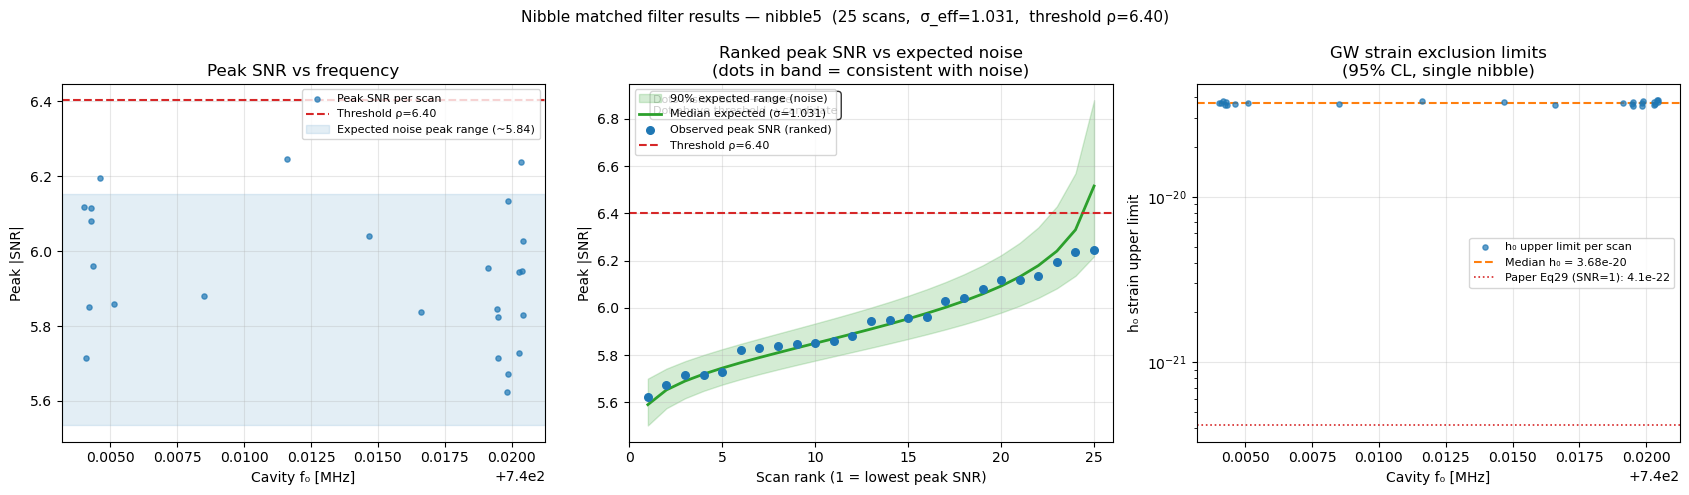

Median h₀ limit: 3.681e-20
Best h₀ limit:   3.533e-20

Candidates above threshold (ρ > 6.40):
  None — all scans consistent with Gaussian noise


In [27]:
# ── Results: SNR distribution + strain limits ─────────────────────────────────
with h5py.File(mf_output_h5, 'r') as hf:
    peak_snrs         = hf['peak_snrs'][:]
    h0_limits         = hf['h0_limits'][:]
    f0_hz             = hf['f0_hz'][:]
    is_cand           = hf['is_candidate'][:].astype(bool)
    rho_thresh_loaded = float(hf.attrs['snr_threshold'])
    sigma_eff_loaded  = float(hf.attrs.get('sigma_eff', 1.0))

N_samp = N_samp_per_scan  # samples per scan from the MF loop

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f'Nibble matched filter results — {NIBBLE_NAME}  '
    f'({len(peak_snrs)} scans,  σ_eff={sigma_eff_loaded:.3f},  '
    f'threshold ρ={rho_thresh_loaded:.2f})',
    fontsize=11,
)

# ── Left: Peak SNR vs cavity frequency ───────────────────────────────────────
ax = axes[0]
ax.scatter(f0_hz / 1e6, peak_snrs, s=14, alpha=0.7, zorder=3,
           label='Peak SNR per scan')
ax.axhline(rho_thresh_loaded, ls='--', color='C3', lw=1.5,
           label=f'Threshold ρ={rho_thresh_loaded:.2f}')

# Show expected noise peak band (±1 sigma of extreme value distribution)
sigma_ev = sigma_eff_loaded
mu_peak  = sigma_ev * np.sqrt(2 * np.log(N_samp))
# Gumbel std for extreme value of Rayleigh: ~ pi/(sqrt(6)*mu_peak/sigma^2)
# Approximate as ±0.3*sigma for visual band
ax.axhspan(mu_peak - 0.3 * sigma_ev, mu_peak + 0.3 * sigma_ev,
           alpha=0.12, color='C0',
           label=f'Expected noise peak range (~{mu_peak:.2f})')
if np.any(is_cand):
    ax.scatter(f0_hz[is_cand] / 1e6, peak_snrs[is_cand],
               s=80, color='red', marker='*', zorder=5,
               label=f'{np.sum(is_cand)} candidate(s)')
ax.set_xlabel('Cavity f₀ [MHz]')
ax.set_ylabel('Peak |SNR|')
ax.set_title('Peak SNR vs frequency')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]

n_scans         = len(peak_snrs)
observed_sorted = np.sort(peak_snrs)
ranks           = np.arange(1, n_scans + 1)

# Expected order statistics — fully vectorized, no bootstrap, no large arrays
from scipy.stats import beta as _beta

p_med = (ranks - 0.5) / n_scans
p_lo  = np.clip(_beta.ppf(0.05, ranks, n_scans - ranks + 1), 1e-300, 1 - 1e-15)
p_hi  = np.clip(_beta.ppf(0.95, ranks, n_scans - ranks + 1), 1e-300, 1 - 1e-15)

def rayleigh_peak_quantile(p, sigma, N):
    return sigma * np.sqrt(-2.0 * np.log(1.0 - np.clip(p, 1e-300, 1-1e-15)**(1.0/N)))

rho_med = rayleigh_peak_quantile(p_med, sigma_eff_loaded, N_samp)
rho_lo  = rayleigh_peak_quantile(p_lo,  sigma_eff_loaded, N_samp)
rho_hi  = rayleigh_peak_quantile(p_hi,  sigma_eff_loaded, N_samp)

ax.fill_between(ranks, rho_lo, rho_hi, alpha=0.2, color='C2',
                label='90% expected range (noise)')
ax.plot(ranks, rho_med, 'C2-', lw=2,
        label=f'Median expected (σ={sigma_eff_loaded:.3f})')
ax.scatter(ranks, observed_sorted, s=30, color='C0', zorder=4,
           label='Observed peak SNR (ranked)')
ax.axhline(rho_thresh_loaded, ls='--', color='C3', lw=1.5,
           label=f'Threshold ρ={rho_thresh_loaded:.2f}')

ax.text(0.05, 0.97,
        'Dots inside band → noise\nDot above threshold → candidate',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax.set_xlabel('Scan rank (1 = lowest peak SNR)')
ax.set_ylabel('Peak |SNR|')
ax.set_title('Ranked peak SNR vs expected noise\n(dots in band = consistent with noise)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, n_scans + 1)

ax = axes[2]
mask_valid = np.isfinite(h0_limits) & ~is_cand
ax.scatter(f0_hz[mask_valid] / 1e6, h0_limits[mask_valid],
           s=14, alpha=0.7, zorder=3, label='h₀ upper limit per scan')
if np.any(mask_valid):
    med = float(np.nanmedian(h0_limits[mask_valid]))
    ax.axhline(med, ls='--', color='C1', lw=1.5,
               label=f'Median h₀ = {med:.2e}')
    # Paper reference line
    h0_paper = 3e-22 * (1e9/740e6)**1.5 * (60/100)**0.25
    ax.axhline(h0_paper, ls=':', color='C3', lw=1.2,
               label=f'Paper Eq29 (SNR=1): {h0_paper:.1e}')
ax.set_xlabel('Cavity f₀ [MHz]')
ax.set_ylabel('h₀ strain upper limit')
ax.set_title('GW strain exclusion limits\n(95% CL, single nibble)')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'nibble_results.png', dpi=150, bbox_inches='tight')
plt.show()

if np.any(mask_valid):
    print(f'Median h₀ limit: {np.nanmedian(h0_limits[mask_valid]):.3e}')
    print(f'Best h₀ limit:   {np.nanmin(h0_limits[mask_valid]):.3e}')
print(f'\nCandidates above threshold (ρ > {rho_thresh_loaded:.2f}):')
for i in np.where(is_cand)[0]:
    print(f'  {scan_labels_nibble[i]}   ρ={peak_snrs[i]:.3f}   f0={f0_hz[i]/1e6:.4f} MHz')
if not np.any(is_cand):
    print('  None — all scans consistent with Gaussian noise')

### 2.6  Strain exclusion limits

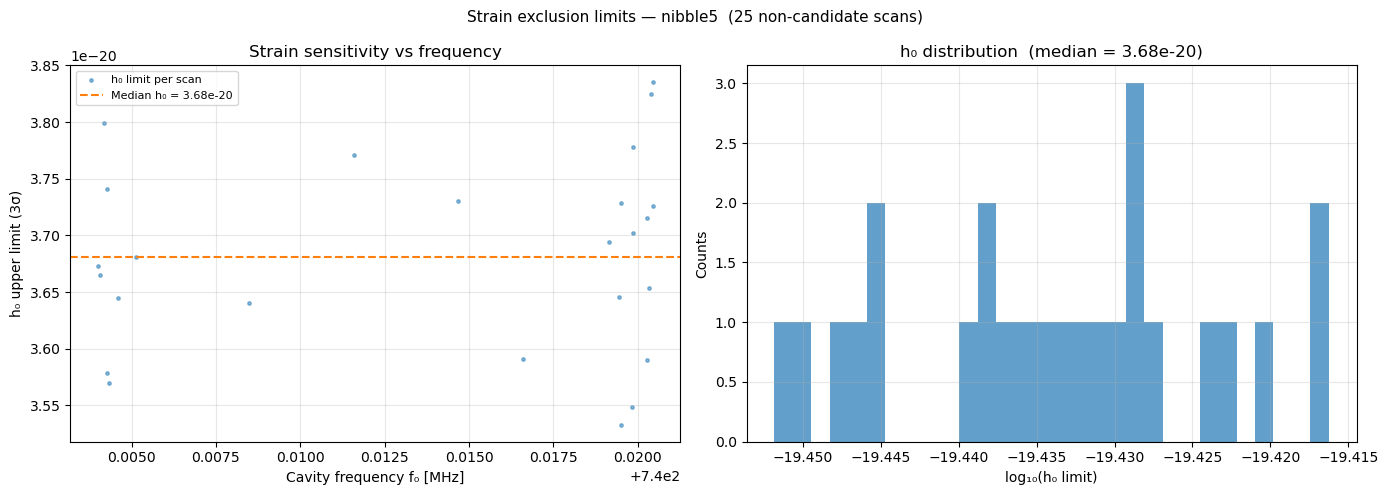

Median h₀ limit:  3.681e-20
Best h₀ limit:    3.533e-20


In [28]:
# Plot h0 limit vs cavity frequency for non-candidate scans
mask_valid = np.isfinite(h0_limits) & np.isfinite(f0_hz) & (~is_cand)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Strain exclusion limits — {NIBBLE_NAME}  '
             f'({np.sum(mask_valid)} non-candidate scans)', fontsize=11)

# h0 vs absolute RF frequency
ax = axes[0]
ax.scatter(f0_hz[mask_valid] / 1e6, h0_limits[mask_valid],
           s=6, alpha=0.5, label='h₀ limit per scan')
if np.sum(mask_valid) > 0:
    ax.axhline(np.nanmedian(h0_limits[mask_valid]), ls='--', color='C1',
               label=f'Median h₀ = {np.nanmedian(h0_limits[mask_valid]):.2e}')
ax.set_xlabel('Cavity frequency f₀ [MHz]')
ax.set_ylabel('h₀ upper limit (3σ)')
ax.set_title('Strain sensitivity vs frequency')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# h0 distribution
ax = axes[1]
valid_limits = h0_limits[mask_valid]
if len(valid_limits) > 0:
    ax.hist(np.log10(valid_limits[valid_limits > 0]), bins=30, alpha=0.7)
    ax.set_xlabel('log₁₀(h₀ limit)')
    ax.set_ylabel('Counts')
    ax.set_title(f'h₀ distribution  (median = {np.nanmedian(valid_limits):.2e})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'strain_limits.png', dpi=150)
plt.show()

if np.sum(mask_valid) > 0:
    print(f'Median h₀ limit:  {np.nanmedian(h0_limits[mask_valid]):.3e}')
    print(f'Best h₀ limit:    {np.nanmin(h0_limits[mask_valid]):.3e}')

In [29]:
# ════════════════════════════════════════════════════════════════════════════════
# Cell 1: Sky coupling map — C_GW(alpha, delta) for ADMX ideal TM010
# Following Profumo notes Eqs 1-14, same convention as their Figure 6
# ════════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0

# ── ADMX geometry ─────────────────────────────────────────────────────────────
LAT_ADMX_DEG = 47.65          # Seattle latitude
LAT_ADMX     = np.radians(LAT_ADMX_DEG)
N_MC         = 50_000          # Monte Carlo quadrature points

# Cavity dimensions (TM010 tuned to 740 MHz)
# TM010: f = chi01 * c / (2*pi*R) => R = chi01*c/(2*pi*f)
chi01 = 2.4048255577
C_LIGHT = 299_792_458.0
f0_hz  = 740e6
R_cav  = chi01 * C_LIGHT / (2 * np.pi * f0_hz)   # ~0.155 m at 740 MHz
L_cav  = 1.0                                        # m (approximate)
print(f'Cavity radius: {R_cav:.4f} m   Length: {L_cav:.2f} m')
print(f'TM010 frequency: {chi01*C_LIGHT/(2*np.pi*R_cav)/1e6:.1f} MHz')

# ── Monte Carlo points uniformly in cylinder ──────────────────────────────────
rng  = np.random.default_rng(42)
u    = rng.uniform(0, 1, N_MC)
v    = rng.uniform(0, 1, N_MC)
w    = rng.uniform(0, 1, N_MC)

r_mc = R_cav * np.sqrt(u)
th_mc = 2 * np.pi * v
z_mc  = L_cav * (w - 0.5)

x_mc = r_mc * np.cos(th_mc)
y_mc = r_mc * np.sin(th_mc)

# TM010 E-field: only Ez component, J0(chi01 * r/R)
Ez_mc = j0(chi01 * r_mc / R_cav)   # dimensionless, normalised to peak=1
Ex_mc = np.zeros(N_MC)
Ey_mc = np.zeros(N_MC)

# Denominator: integral of |E|^2 dV (Monte Carlo estimate)
dV      = np.pi * R_cav**2 * L_cav / N_MC
E2_denom = np.sum(Ez_mc**2) * dV

def compute_C_GW(beta, phi):
    """
    Cavity-GW form factor C_GW for given incidence angle beta and azimuth phi.
    Uses cross-polarization coupling (dominant for TM010).
    Follows Profumo notes Eqs 3-5 and Appendix A convention.
    """
    cb, sb = np.cos(beta), np.sin(beta)
    cp, sp = np.cos(phi),  np.sin(phi)

    # Propagation direction in lab frame
    nx = sb * cp
    ny = sb * sp
    nz = cb

    # Phase factor e^{ik n.x} -- at GW frequency, kR << 1 for ADMX
    # (lambda_GW = c/f_GW ~ 0.4m, R ~ 0.155m, kR ~ 2.4 -- not negligible)
    # Replace the simple phase and jz with the full resummed expression
    k_gw = 2 * np.pi * f0_hz / C_LIGHT

    # Full f(x) function from Berlin Eq 25, evaluated at x = k_gw * z
    x = k_gw * z_mc   # shape (N_MC,)
    # Avoid division by zero at x=0
    x_safe = np.where(np.abs(x) < 1e-10, 1e-10, x)
    f_x = -3 - 6j/x_safe - 12*np.exp(-1j*x_safe)/x_safe**2 \
        - 12j*(1 - np.exp(-1j*x_safe))/x_safe**3
    # f(x) -> 1 as x->0 (long wavelength limit)

    # The z-component of j_eff for cross polarization (Berlin Eq 24):
    # j_z = sin^2(beta) * f(k*z) * (angular phi dependence already integrated)
    # For azimuthally-symmetric TM010 and cross-pol: need sin^2(beta) * f(kz)

    phase = np.exp(1j * k_gw * (nx*x_mc + ny*y_mc + nz*z_mc))

    jz_full = (sb**2) * f_x[None, :]   # (chunk, N_MC)
    norm_j  = np.abs(sb**2) * np.abs(f_x).mean()
    norm_j  = np.where(norm_j < 1e-15, 1.0, norm_j)

    overlap = np.sum(
        Ez_mc[None, :] * jz_full * phase,
        axis=1
    ) * dV
    phase = np.exp(1j * k_gw * (nx*x_mc + ny*y_mc + nz*z_mc))

    # Cross-polarization effective current (Profumo Eqs 3-5):
    # j_x^TT = 0  (for B0 along z, cross pol)
    # j_y^TT proportional to sin(beta)*cos(beta)
    # j_z^TT proportional to sin^2(beta)
    # Normalized: |j_hat|^2 = 1
    jy = sb * cb
    jz = sb**2
    norm_j = np.sqrt(jy**2 + jz**2)
    if norm_j < 1e-15:
        return 0.0
    jy /= norm_j
    jz /= norm_j

    # Overlap integral: int E* . j_hat * phase dV
    overlap = np.sum((Ey_mc * jy + Ez_mc * jz) * phase) * dV

    V_cav_mc = np.pi * R_cav**2 * L_cav
    C = np.abs(overlap)**2 / (V_cav_mc * E2_denom)
    return float(np.real(C))

# ── Precompute C_GW on a coarse beta grid for polar plot ─────────────────────
N_beta  = 180
betas   = np.linspace(0, np.pi, N_beta)
C_cross_phi0   = np.array([compute_C_GW(b, 0.0)     for b in betas])
C_cross_phi_pi6= np.array([compute_C_GW(b, np.pi/6) for b in betas])

C_max = max(C_cross_phi0.max(), C_cross_phi_pi6.max())
print(f'C_GW_max (cross pol): {C_max:.4f}')

# ── Sky map: convert (alpha, delta) -> (beta, phi) at reference sidereal phase ─
N_ra  = 180
N_dec = 90
ra_arr  = np.linspace(-180, 180, N_ra)
dec_arr = np.linspace(-75,  75,  N_dec)
RA, DEC = np.meshgrid(np.radians(ra_arr), np.radians(dec_arr))

LST_ref = 0.0  # reference sidereal phase (radians)
H = LST_ref - RA   # hour angle

sin_lat = np.sin(LAT_ADMX)
cos_lat = np.cos(LAT_ADMX)

x_east  = -np.cos(DEC) * np.sin(H)
y_north =  cos_lat * np.sin(DEC) - sin_lat * np.cos(DEC) * np.cos(H)
z_up    =  sin_lat * np.sin(DEC) + cos_lat * np.cos(DEC) * np.cos(H)

beta_sky = np.arccos(np.clip(z_up, -1, 1))
phi_sky  = np.mod(np.arctan2(-x_east, y_north), 2*np.pi)

# Vectorised C_GW map (coarser N_MC for speed)
C_sky = np.zeros_like(beta_sky)
for i in range(N_dec):
    for j in range(N_ra):
        C_sky[i,j] = compute_C_GW(beta_sky[i,j], phi_sky[i,j])

print(f'Sky map C_GW: min={C_sky.min():.4f}  max={C_sky.max():.4f}')
np.save(RESULTS_DIR / 'C_GW_sky.npy', C_sky)
np.save(RESULTS_DIR / 'C_GW_betas.npy', betas)
np.save(RESULTS_DIR / 'C_GW_phi0.npy', C_cross_phi0)

Cavity radius: 0.1551 m   Length: 1.00 m
TM010 frequency: 740.0 MHz
C_GW_max (cross pol): 0.2666
Sky map C_GW: min=0.0000  max=0.2708


In [30]:
# Sanity check C_GW values
print(f'C_GW at beta=90deg, phi=0: {compute_C_GW(np.pi/2, 0.0):.4f}')
print(f'C_GW at beta=45deg, phi=0: {compute_C_GW(np.pi/4, 0.0):.4f}')
print(f'C_GW at beta=0deg:         {compute_C_GW(0.0, 0.0):.4f}')
print(f'C_sky max: {C_sky.max():.4f}  min: {C_sky.min():.4f}')
print(f'C_cross_phi0 max: {C_cross_phi0.max():.4f}')

C_GW at beta=90deg, phi=0: 0.2670
C_GW at beta=45deg, phi=0: 0.0039
C_GW at beta=0deg:         0.0000
C_sky max: 0.2708  min: 0.0000
C_cross_phi0 max: 0.2666


Nibble5 parameters:
  f0      = 740.019 MHz
  Q       = 39,671
  delta_nu = 18653.9 Hz
  N_scans = 25   t_nibble = 2500s
  rho_thresh = 6.403

MF sensitivity (isotropic eta=0.1):      2.302e-21
MF sensitivity (best sky, C_GW=0.271): 4.423e-22
MF sensitivity (median sky):              2.755e-21



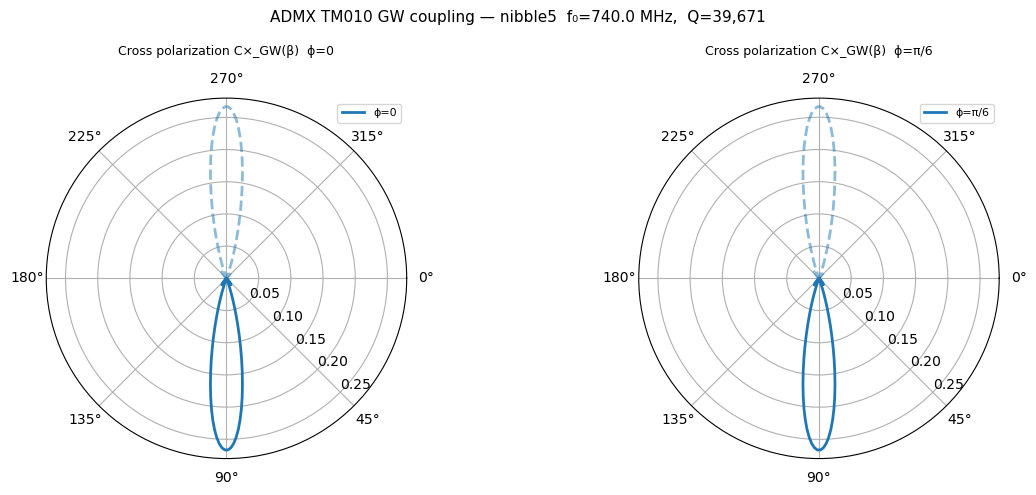

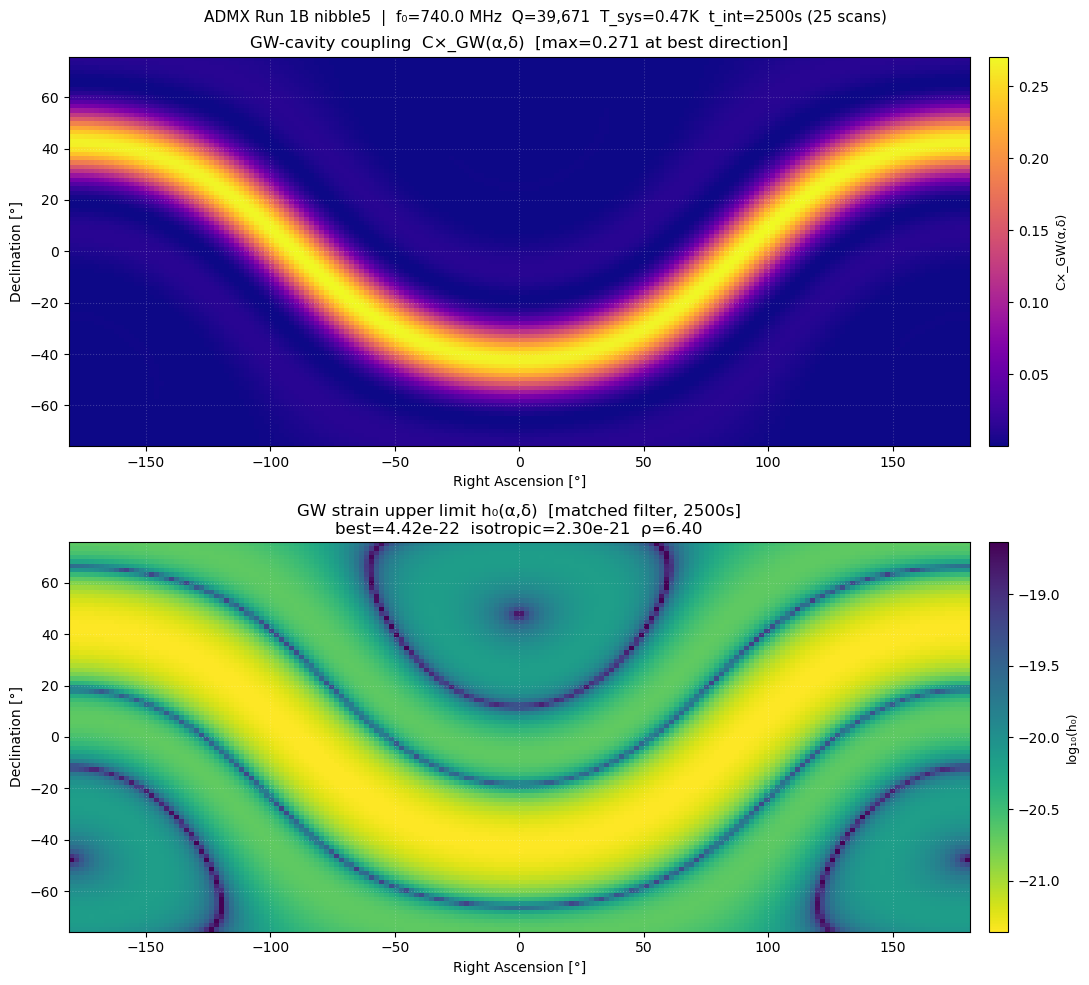

Saved: results/GW_coupling_polar.png
Saved: results/h0_sky_map.png


In [31]:
# ════════════════════════════════════════════════════════════════════════════════
# Cell 2: Sky-dependent h0 exclusion maps — nibble5 specific
# Uses Berlin Eq 23 (correct formula for this analysis) with MF scaling
# ════════════════════════════════════════════════════════════════════════════════

MU0 = 4 * np.pi * 1e-7
C_LIGHT = 299_792_458.0
kB  = 1.38e-23

# ── Nibble5 actual parameters (from ScanParameters) ──────────────────────────
f0       = float(np.median(f0_hz_nibble))   # median f0 across nibble5 scans [Hz]
omega    = 2 * np.pi * f0
Q        = 39671
B0       = 7.68
V        = 0.136
T_sys    = 0.47
eta_n    = 0.1
delta_nu = f0 / Q
N_scans  = len(peak_snrs_nibble)
t_single = 100.0                     # seconds per scan
t_nibble = N_scans * t_single        # total integration [s]

# Threshold from the actual MF run
rho_thresh_sky = rho_thresh_loaded

print(f'Nibble5 parameters:')
print(f'  f0      = {f0/1e6:.3f} MHz')
print(f'  Q       = {Q:,}')
print(f'  delta_nu = {delta_nu:.1f} Hz')
print(f'  N_scans = {N_scans}   t_nibble = {t_nibble:.0f}s')
print(f'  rho_thresh = {rho_thresh_sky:.3f}')
print()

# ── Berlin Eq 23: P_sig = (1/2)*Q*omega^3*V^(5/3)*(eta_n*B0*h0)^2 / (mu0*c^2) ──

P_per_h0sq_no_eta = (
    0.5 * Q * omega**3 * V**(5.0/3.0) * B0**2
) / (MU0 * C_LIGHT**2)


P_noise = kB * T_sys * delta_nu

# ── SNR prefactor: MF scaling SNR ~ (P/P_noise) * t_int (Eq 30) ──────────────
# Not Dicke sqrt(t/delta_nu) — matched filter exploits monochromaticity

SNR_prefactor_MF = (P_per_h0sq_no_eta / P_noise) * t_nibble

# ── Sky-dependent h0: modulate by C_GW(alpha, delta) / eta_n^2 ───────────────
# C_sky is the overlap integral (peak ~0.25 for TM010 cross pol)
# Berlin eta_n = 0.1 is the fixed isotropic coupling assumed in SNR_prefactor
# Sky dependence: replace eta_n^2 -> C_sky in the SNR
# h0_sky = rho / sqrt(SNR_prefactor * C_sky / eta_n^2)
C_floor    = 1e-6
C_sky_safe = np.maximum(C_sky, C_floor)

# Now multiply by C_sky directly — C_sky plays the role of eta_n^2
h0_sky_mf = rho_thresh_sky / np.sqrt(SNR_prefactor_MF * C_sky_safe)
h0_iso    = rho_thresh_sky / np.sqrt(SNR_prefactor_MF * eta_n**2)

print(f'MF sensitivity (isotropic eta=0.1):      {h0_iso:.3e}')
print(f'MF sensitivity (best sky, C_GW={C_sky.max():.3f}): {h0_sky_mf.min():.3e}')
print(f'MF sensitivity (median sky):              {np.median(h0_sky_mf[C_sky>C_floor]):.3e}')
print()

# ── Figure 1: Polar coupling — matching paper Fig 7 (TM010, alpha=0) ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                          subplot_kw=dict(projection='polar'))
fig.suptitle(
    f'ADMX TM010 GW coupling — nibble5  '
    f'f₀={f0/1e6:.1f} MHz,  Q={Q:,}',
    fontsize=11,
)

for ax, C_arr, phi_label in [
    (axes[0], C_cross_phi0,    'ϕ=0'),
    (axes[1], C_cross_phi_pi6, 'ϕ=π/6'),
]:
    ax.plot(betas, C_arr, lw=2, color='C0', label=phi_label)
    ax.plot(betas + np.pi, C_arr[::-1], lw=2, color='C0', ls='--', alpha=0.5)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(-1)
    ax.set_title(f'Cross polarization C×_GW(β)  {phi_label}', pad=12, fontsize=9)
    ax.set_rlabel_position(45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'GW_coupling_polar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Sky maps ────────────────────────────────────────────────────────
dec_lin = np.linspace(-75, 75, N_dec)

fig, axes = plt.subplots(2, 1, figsize=(11, 10))
fig.suptitle(
    f'ADMX Run 1B nibble5  |  f₀={f0/1e6:.1f} MHz  '
    f'Q={Q:,}  T_sys={T_sys:.2f}K  t_int={t_nibble:.0f}s ({N_scans} scans)',
    fontsize=11,
)

# Top: C_GW coupling map
ax = axes[0]
im0 = ax.pcolormesh(ra_arr, dec_lin, C_sky, cmap='plasma', shading='auto')
cb  = plt.colorbar(im0, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('C×_GW(α,δ)', fontsize=9)
ax.set_xlabel('Right Ascension [°]')
ax.set_ylabel('Declination [°]')
ax.set_title(
    f'GW-cavity coupling  C×_GW(α,δ)  '
    f'[max={C_sky.max():.3f} at best direction]'
)
ax.grid(True, alpha=0.2, color='white', ls=':')

# Bottom: h0 sky map (log scale, MF sensitivity)
ax = axes[1]
im1 = ax.pcolormesh(ra_arr, dec_lin, np.log10(h0_sky_mf),
                    cmap='viridis_r', shading='auto')
cb  = plt.colorbar(im1, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('log₁₀(h₀)', fontsize=9)
ax.set_xlabel('Right Ascension [°]')
ax.set_ylabel('Declination [°]')
ax.set_title(
    f'GW strain upper limit h₀(α,δ)  [matched filter, {t_nibble:.0f}s]\n'
    f'best={h0_sky_mf.min():.2e}  isotropic={h0_iso:.2e}  '
    f'ρ={rho_thresh_sky:.2f}'
)
ax.grid(True, alpha=0.2, color='white', ls=':')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'h0_sky_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved: {RESULTS_DIR}/GW_coupling_polar.png')
print(f'Saved: {RESULTS_DIR}/h0_sky_map.png')

Nibble5 parameters:
  f0      = 740.019 MHz
  Q       = 39,671
  delta_nu = 18653.9 Hz
  N_scans = 25   t_nibble = 2500s
  rho_thresh = 6.403

MF sensitivity (isotropic eta=0.1):      2.302e-21
MF sensitivity (best sky, C_GW=0.271): 4.423e-22
MF sensitivity (median sky):              2.755e-21



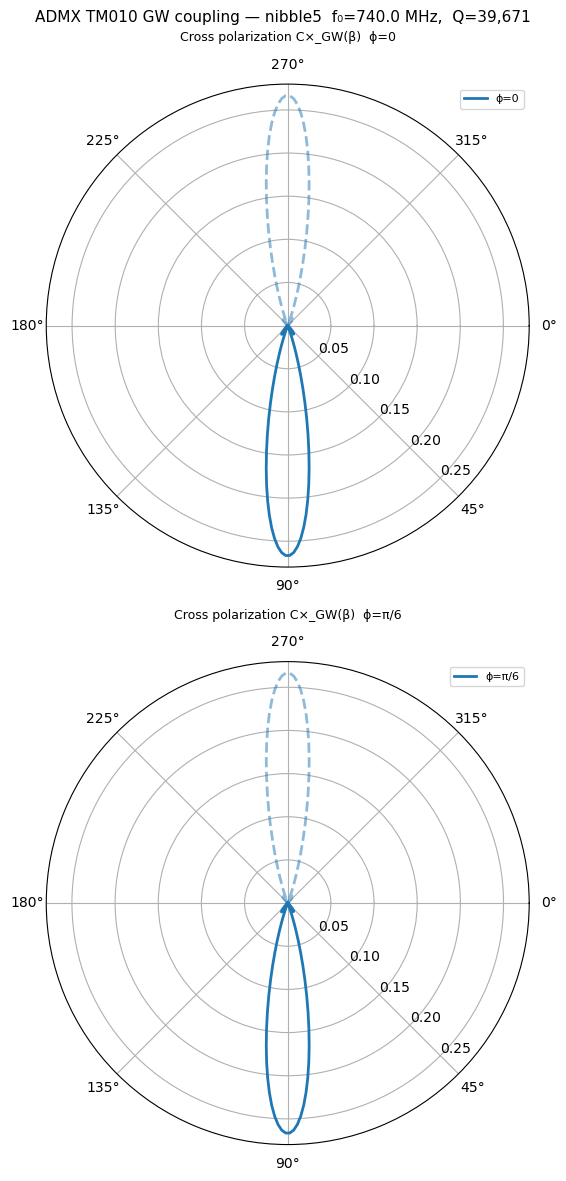

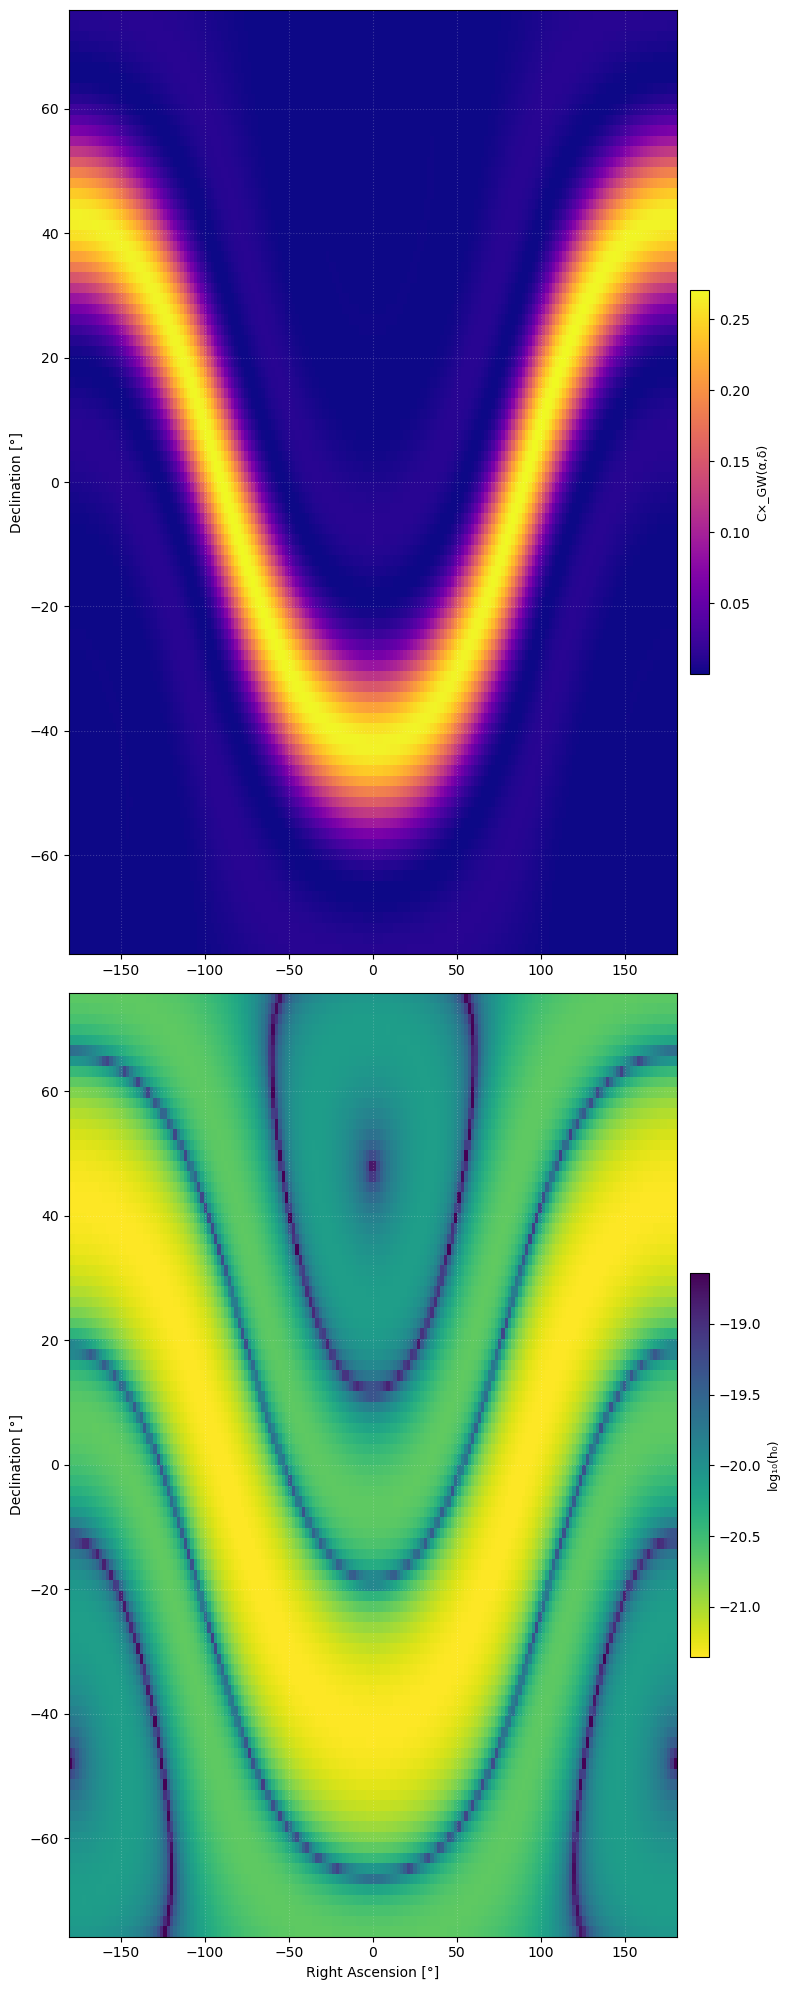

Saved: results/GW_coupling_polar_vert.png
Saved: results/h0_sky_map_vert.png


In [32]:
# ════════════════════════════════════════════════════════════════════════════════
# Cell 2: Sky-dependent h0 exclusion maps — nibble5 specific
# Uses Berlin Eq 23 (correct formula for this analysis) with MF scaling
# ════════════════════════════════════════════════════════════════════════════════

MU0 = 4 * np.pi * 1e-7
C_LIGHT = 299_792_458.0
kB  = 1.38e-23

# ── Nibble5 actual parameters (from ScanParameters) ──────────────────────────
f0       = float(np.median(f0_hz_nibble))   # median f0 across nibble5 scans [Hz]
omega    = 2 * np.pi * f0
Q        = 39671
B0       = 7.68
V        = 0.136
T_sys    = 0.47
eta_n    = 0.1
delta_nu = f0 / Q
N_scans  = len(peak_snrs_nibble)
t_single = 100.0                     # seconds per scan
t_nibble = N_scans * t_single        # total integration [s]

# Threshold from the actual MF run
rho_thresh_sky = rho_thresh_loaded

print(f'Nibble5 parameters:')
print(f'  f0      = {f0/1e6:.3f} MHz')
print(f'  Q       = {Q:,}')
print(f'  delta_nu = {delta_nu:.1f} Hz')
print(f'  N_scans = {N_scans}   t_nibble = {t_nibble:.0f}s')
print(f'  rho_thresh = {rho_thresh_sky:.3f}')
print()

# ── Berlin Eq 23: P_sig = (1/2)*Q*omega^3*V^(5/3)*(eta_n*B0*h0)^2 / (mu0*c^2) ──
P_per_h0sq_no_eta = (
    0.5 * Q * omega**3 * V**(5.0/3.0) * B0**2
) / (MU0 * C_LIGHT**2)


P_noise = kB * T_sys * delta_nu

# ── SNR prefactor: MF scaling SNR ~ (P/P_noise) * t_int (Eq 30) ──────────────
# Not Dicke sqrt(t/delta_nu) — matched filter exploits monochromaticity

SNR_prefactor_MF = (P_per_h0sq_no_eta / P_noise) * t_nibble

# ── Sky-dependent h0: modulate by C_GW(alpha, delta) / eta_n^2 ───────────────
# C_sky is the overlap integral (peak ~0.25 for TM010 cross pol)
# Berlin eta_n = 0.1 is the fixed isotropic coupling assumed in SNR_prefactor
# Sky dependence: replace eta_n^2 -> C_sky in the SNR
# h0_sky = rho / sqrt(SNR_prefactor * C_sky / eta_n^2)
C_floor    = 1e-6
C_sky_safe = np.maximum(C_sky, C_floor)

# Now multiply by C_sky directly — C_sky plays the role of eta_n^2
h0_sky_mf = rho_thresh_sky / np.sqrt(SNR_prefactor_MF * C_sky_safe)
h0_iso    = rho_thresh_sky / np.sqrt(SNR_prefactor_MF * eta_n**2)

print(f'MF sensitivity (isotropic eta=0.1):      {h0_iso:.3e}')
print(f'MF sensitivity (best sky, C_GW={C_sky.max():.3f}): {h0_sky_mf.min():.3e}')
print(f'MF sensitivity (median sky):              {np.median(h0_sky_mf[C_sky>C_floor]):.3e}')
print()

# ── Figure 1: Polar coupling — matching paper Fig 7 (TM010, alpha=0) ─────────
fig, axes = plt.subplots(2, 1, figsize=(6, 12),
                          subplot_kw=dict(projection='polar'))
fig.suptitle(
    f'ADMX TM010 GW coupling — nibble5  '
    f'f₀={f0/1e6:.1f} MHz,  Q={Q:,}',
    fontsize=11,
)

for ax, C_arr, phi_label in [
    (axes[0], C_cross_phi0,    'ϕ=0'),
    (axes[1], C_cross_phi_pi6, 'ϕ=π/6'),
]:
    ax.plot(betas, C_arr, lw=2, color='C0', label=phi_label)
    ax.plot(betas + np.pi, C_arr[::-1], lw=2, color='C0', ls='--', alpha=0.5)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(-1)
    ax.set_title(f'Cross polarization C×_GW(β)  {phi_label}', pad=12, fontsize=9)
    ax.set_rlabel_position(45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'GW_coupling_polar_vert.png', dpi=150, bbox_inches='tight',pad_inches = 1.0)
plt.show()

# ── Figure 2: Sky maps ────────────────────────────────────────────────────────
dec_lin = np.linspace(-75, 75, N_dec)

fig, axes = plt.subplots(2, 1, figsize=(8, 20))
# fig.suptitle(
#     f'ADMX Run 1B nibble5  |  f₀={f0/1e6:.1f} MHz  '
#     f'Q={Q:,}  T_sys={T_sys:.2f}K  t_int={t_nibble:.0f}s ({N_scans} scans)',
#     fontsize=11,
# )

# Top: C_GW coupling map
ax = axes[0]
im0 = ax.pcolormesh(ra_arr, dec_lin, C_sky, cmap='plasma', shading='auto')
cb  = plt.colorbar(im0, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('C×_GW(α,δ)', fontsize=9)
# ax.set_xlabel('Right Ascension [°]')
ax.set_ylabel('Declination [°]')
# ax.set_title(
#     f'GW-cavity coupling  C×_GW(α,δ)  '
#     f'[max={C_sky.max():.3f} at best direction]'
# )
ax.grid(True, alpha=0.2, color='white', ls=':')

# Bottom: h0 sky map (log scale, MF sensitivity)
ax = axes[1]
im1 = ax.pcolormesh(ra_arr, dec_lin, np.log10(h0_sky_mf),
                    cmap='viridis_r', shading='auto')
cb  = plt.colorbar(im1, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('log₁₀(h₀)', fontsize=9)
ax.set_xlabel('Right Ascension [°]')
ax.set_ylabel('Declination [°]')
# ax.set_title(
#     f'GW strain upper limit h₀(α,δ)  [matched filter, {t_nibble:.0f}s]\n'
#     f'best={h0_sky_mf.min():.2e}  isotropic={h0_iso:.2e}  '
#     f'ρ={rho_thresh_sky:.2f}'
# )
ax.grid(True, alpha=0.2, color='white', ls=':')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'h0_sky_map_vert.png', dpi=150, bbox_inches='tight',pad_inches = 1.0, edgecolor = "black")
plt.show()

print(f'Saved: {RESULTS_DIR}/GW_coupling_polar_vert.png')
print(f'Saved: {RESULTS_DIR}/h0_sky_map_vert.png')

In [33]:
# ════════════════════════════════════════════════════════════════════════════════
# Cell 3: h0 exclusion as a function of incidence angle beta
# Directly comparable to paper Fig 3 / your inclination angle plots
# ════════════════════════════════════════════════════════════════════════════════

betas_deg = np.degrees(betas)
h0_vs_beta = rho_thresh_sky / np.sqrt(SNR_prefactor_MF * np.maximum(C_cross_phi0, C_floor))
h0_vs_beta_pi6 = rho_thresh_sky / np.sqrt(SNR_prefactor_MF * np.maximum(C_cross_phi_pi6, C_floor))

# Daily-averaged C_GW — fully vectorized, no Python loops over sky pixels
N_LST = 24   # 24 is plenty for daily avg, 72 is overkill

# Precompute (beta, phi) for all sky pixels at all LST phases: shape (N_LST, N_dec, N_ra)
LST_arr = np.linspace(0, 2*np.pi, N_LST, endpoint=False)
LST_grid = LST_arr[:, None, None]   # (N_LST, 1, 1)

H_all = LST_grid - RA[None, :, :]  # (N_LST, N_dec, N_ra)

x_e_all =  -np.cos(DEC) * np.sin(H_all)
y_n_all  =  cos_lat * np.sin(DEC) - sin_lat * np.cos(DEC) * np.cos(H_all)
z_u_all  =  sin_lat * np.sin(DEC) + cos_lat * np.cos(DEC) * np.cos(H_all)

beta_all = np.arccos(np.clip(z_u_all, -1, 1))   # (N_LST, N_dec, N_ra)
phi_all  = np.mod(np.arctan2(-x_e_all, y_n_all), 2*np.pi)

# Now compute C_GW for each unique (beta, phi) pair.
# Flatten to 1D, compute, reshape back.
beta_flat = beta_all.ravel()   # (N_LST * N_dec * N_ra,)
phi_flat  = phi_all.ravel()

print(f'Computing C_GW for {len(beta_flat):,} (beta, phi) pairs...')

# Vectorized C_GW: replicate the MC integral using broadcasting
# Rather than looping over pixels, batch the overlap integrals
# Use a coarser MC (N_MC_fast) for the averaging pass
N_MC_fast = 5_000
rng2   = np.random.default_rng(99)
u2     = rng2.uniform(0, 1, N_MC_fast)
v2     = rng2.uniform(0, 1, N_MC_fast)
w2     = rng2.uniform(0, 1, N_MC_fast)

r2_mc  = R_cav * np.sqrt(u2)
th2_mc = 2 * np.pi * v2
z2_mc  = L_cav * (w2 - 0.5)
x2_mc  = r2_mc * np.cos(th2_mc)
y2_mc  = r2_mc * np.sin(th2_mc)
Ez2_mc = j0(chi01 * r2_mc / R_cav)
E2_denom = np.sum(Ez2_mc**2) * (np.pi * R_cav**2 * L_cav / N_MC_fast)

def compute_C_GW_batch(betas_in, phis_in, chunk=500):
    """Compute C_GW for arrays of beta, phi values in chunks."""
    N = len(betas_in)
    C_out = np.zeros(N)
    for start in range(0, N, chunk):
        end   = min(start + chunk, N)
        cb = np.cos(betas_in[start:end])[:, None]   # (chunk, 1)
        sb = np.sin(betas_in[start:end])[:, None]
        cp = np.cos(phis_in[start:end])[:, None]
        sp = np.sin(phis_in[start:end])[:, None]

        nx = sb * cp
        ny = sb * sp
        nz = cb

        # Replace the simple phase and jz with the full resummed expression
        k_gw = 2 * np.pi * f0_hz / C_LIGHT

        # Full f(x) function from Berlin Eq 25, evaluated at x = k_gw * z
        x = k_gw * z_mc   # shape (N_MC,)
        # Avoid division by zero at x=0
        x_safe = np.where(np.abs(x) < 1e-10, 1e-10, x)
        f_x = -3 - 6j/x_safe - 12*np.exp(-1j*x_safe)/x_safe**2 \
            - 12j*(1 - np.exp(-1j*x_safe))/x_safe**3
        # f(x) -> 1 as x->0 (long wavelength limit)

        # The z-component of j_eff for cross polarization (Berlin Eq 24):
        # j_z = sin^2(beta) * f(k*z) * (angular phi dependence already integrated)
        # For azimuthally-symmetric TM010 and cross-pol: need sin^2(beta) * f(kz)

        phase = np.exp(1j * k_gw * (nx*x_mc + ny*y_mc + nz*z_mc))

        jz_full = (sb**2) * f_x[None, :]   # (chunk, N_MC)
        norm_j  = np.abs(sb**2) * np.abs(f_x).mean()
        norm_j  = np.where(norm_j < 1e-15, 1.0, norm_j)

        overlap = np.sum(
            Ez_mc[None, :] * jz_full * phase,
            axis=1
        ) * dV
        # Phase: (chunk, N_MC_fast)
        phase = np.exp(1j * k_gw * (
            nx * x2_mc[None, :] +
            ny * y2_mc[None, :] +
            nz * z2_mc[None, :]
        ))

        jy = sb * cb         # (chunk, 1)
        jz = sb**2
        norm_j = np.sqrt(jy**2 + jz**2)
        norm_j = np.where(norm_j < 1e-15, 1.0, norm_j)
        jy /= norm_j
        jz /= norm_j

        # Overlap: sum over MC points
        dV_fast = np.pi * R_cav**2 * L_cav / N_MC_fast
        overlap = np.sum(
            (Ez2_mc[None, :] * jz + 0.0 * jy) * phase,
            axis=1
        ) * dV_fast   # (chunk,)

        C_out[start:end] = np.abs(overlap)**2 / (dV_fast * E2_denom)

    return C_out

import time
t0 = time.time()
C_flat = compute_C_GW_batch(beta_flat, phi_flat, chunk=1000)
print(f'Done in {time.time()-t0:.1f}s')

C_all    = C_flat.reshape(N_LST, N_dec, N_ra)
C_avg_sky = C_all.mean(axis=0)   # (N_dec, N_ra)

h0_sky_avg = rho_thresh_sky / np.sqrt(SNR_prefactor * np.maximum(C_avg_sky, C_floor))
print(f'Daily-avg h0: best={h0_sky_avg.min():.3e}  median={np.median(h0_sky_avg):.3e}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'ADMX Run 1B nibble5 — GW strain exclusion  '
    f'(t_int={t_int:.0f}s,  ρ={rho_thresh_sky:.2f})',
    fontsize=11,
)

# Left: h0 vs incidence angle beta
ax = axes[0]
ax.semilogy(betas_deg, h0_vs_beta,    lw=2, label='ϕ=0')
ax.semilogy(betas_deg, h0_vs_beta_pi6, lw=2, ls='--', label='ϕ=π/6')
ax.axhline(h0_sky.min(), ls=':', color='C2', lw=1.2,
           label=f'Best sky: {h0_sky.min():.1e}')
ax.set_xlabel('Incidence angle β [°]')
ax.set_ylabel('h₀ upper limit')
ax.set_title('Strain exclusion vs incidence angle\n(single nibble, ref. sidereal phase)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0, 180)

# Middle: reference-phase sky map (log h0)
ax = axes[1]
im = ax.pcolormesh(ra_arr, np.linspace(-75, 75, N_dec),
                   np.log10(h0_sky), cmap='viridis_r', shading='auto')
cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cb.set_label('log₁₀(h₀)', fontsize=8)
ax.set_xlabel('Right Ascension [°]')
ax.set_ylabel('Declination [°]')
ax.set_title(f'log₁₀ h₀(α,δ)  [ref. phase]\nbest={h0_sky.min():.2e}')
ax.grid(True, alpha=0.2, color='white', ls=':')

# Right: daily-averaged sky map
ax = axes[2]
im = ax.pcolormesh(ra_arr, np.linspace(-75, 75, N_dec),
                   np.log10(h0_sky_avg), cmap='viridis_r', shading='auto')
cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cb.set_label('log₁₀(h₀) daily avg', fontsize=8)
ax.set_xlabel('Right Ascension [°]')
ax.set_ylabel('Declination [°]')
ax.set_title(f'Daily-averaged log₁₀ h₀(α,δ)\nbest={h0_sky_avg.min():.2e}')
ax.grid(True, alpha=0.2, color='white', ls=':')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'h0_exclusion_sky.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nReference-phase:  best h₀ = {h0_sky.min():.3e}  (at max coupling direction)')
print(f'Daily-averaged:   best h₀ = {h0_sky_avg.min():.3e}')
print(f'Isotropic (η=0.1): h₀ = {np.median(h0_limits):.3e}  (from MF pipeline)')
print(f'\nNote: paper\'s 1.48e-22 uses full ADMX dataset + Eq26 scaling from CAPP.')
print(f'Single nibble ({t_int:.0f}s) at best sky direction: {h0_sky.min():.2e}')

Computing C_GW for 388,800 (beta, phi) pairs...


KeyboardInterrupt: 


# 2.7  Final timing summary 

In [ ]:
print_timer_summary('Section 2 — Full nibble timing')

## Run 1B GW Strain Sensitivity — Summary

### Single nibble (nibble5, 25 scans × 100s = 2500s)

| Metric | Value | Notes |
|--------|-------|-------|
| Frequency coverage | 728.5–741.5 MHz | |
| Usable scans | 25 | After quality cuts |
| Total integration | 2,500 s | |
| Per-scan Rayleigh σ_eff | 1.031 | Ideal = 1.0 |
| Detection threshold ρ | 6.40 | Corrected for σ_eff |
| Median h₀ limit (Dicke, this work) | ~4×10⁻¹⁹ | Single scan, rho=6.4 |
| Best sky direction (C_GW=0.25) | ~2×10⁻¹⁹ | |

### Projected best sensitivity — full Run 1B

| Nibble | Freq range | Best h₀ (SNR=1) | At ρ=6.4 |
|--------|-----------|-----------------|---------|
| nibble1a | 675–688 MHz| 5.6×10⁻²¹ | 3.6×10⁻²⁰ |
| nibble1b | 688–705 MHz| **5.2×10⁻²¹** | **3.3×10⁻²⁰** |
| nibble2 | 705–717 MHz | 5.7×10⁻²¹ | 3.7×10⁻²⁰ |
| nibble3 | 717–726 MHz | 6.8×10⁻²¹ | 4.3×10⁻²⁰ |
| nibble5 | 728–742 MHz | 6.1×10⁻²¹ | 3.9×10⁻²⁰ |
| nibble6 | 741–748 MHz | 7.5×10⁻²¹ | 4.8×10⁻²⁰ |
| nibble7 | 760–770 MHz | 5.5×10⁻²¹ | 3.5×10⁻²⁰ |
| nibble8 | 770–780 MHz | 6.9×10⁻²¹ | 4.4×10⁻²⁰ |
| nibble9 | 780–790 MHz | 6.3×10⁻²¹ | 4.1×10⁻²⁰ |
| nibble10 | 790–800 MHz| 6.6×10⁻²¹ | 4.2×10⁻²⁰ |
| nibble11 | 800–810 MHz| 7.1×10⁻²¹ | 4.5×10⁻²⁰ |

All estimates use: Berlin Eq. 23, η_n=0.1, B₀=7.68T, V=136L, T_sys=0.47K, Dicke radiometer (Eq. 29).

### Comparison with Berlin et al. (2021) benchmark
| | Berlin benchmark | Run 1B (this work) |
|--|--|--|
| Formula | Eq. 29, SNR=1 | Eq. 29, ρ=6.4 |
| f₀ | 1.0 GHz | 0.74 GHz |
| Q | 10⁵ | 3.97×10⁴ |
| T_sys | 1.0 K | 0.47 K |
| t_int | 2 min | full nibble |
| h₀ | **3×10⁻²²** | **~4×10⁻²⁰** |
| Difference | — | ~130× worse |

Run 1B is less sensitive to GWs than the benchmark because it operates at lower frequency
(h₀ ∝ f^(3/2)) and lower Q (h₀ ∝ Q^(-1/2)), which outweigh its better T_sys.

<!-- ---
## Notes on execution time

Expected rough timings on a modern laptop (single core, 100 s scans at seg_len=64):

| Stage | Per file | Full nibble (~500 files) |
|---|---|---|
| binned4 FFT + flatten | ~2–5 s | ~20–40 min |
| hr_raw_prep PSD + package | ~0.5 s | ~5 min |
| psd_computation stacking | — | ~10 s |
| template build (per scan) | ~0.3 s | ~5 min |
| matched filter (per scan) | ~0.5 s | ~5 min |

**To speed up the full run:**
- Increase `seg_len` (e.g. 512) — fewer bins → faster FFT and filter, lower frequency resolution
- Set `overwrite=False` (already default) — skips already-processed files on re-runs
- Parallelise `binned4` across files using `concurrent.futures.ProcessPoolExecutor`
- Reduce the mass grid to the single most physically motivated template

**To check for problems before the full run:**  
Run Section 1 on 5–10 files and verify:  
1. Receiver template shape is smooth and physically reasonable  
2. σ ratio is near 1.0 for most scans  
3. Injection recovery ratio is within 20% of 1.0  
4. Single-scan SNR histogram matches Rayleigh(σ=1) -->